# Исследовательский анализ данных сервиса Яндекс Афиша

- Автор: Басс Наталья
- Дата: 21.08.2026

## Цели и задачи проекта

**Цель проекта** - проанализировать и изучить изменения пользовательского спроса и структуры заказов сервиса Яндекс Афиша летом и осенью 2024 года, выявить наиболее популярные события, регионы и билетных партнёров, а также определить, существуют ли статистически значимые различия в активности пользователей мобильных и стационарных устройств.

**Задачи проекта**:

1. Загрузить данные и изучить их структуру
2. Проверить данные на пропуски, дубликаты, некорректные значения и выбросы
3. Привести выручку к единой валюте (российский рубль)
4. Рассчитать дополнительные показатели, необходимые для анализа
5. Изучить изменение количества заказов по месяцам
6. Сравнить структуру заказов летом и осенью (по типам мероприятий, по типам устройств, по возрастным ограничениям)
7. Проанализировать изменение средней выручки с одного билета для разных типов мероприятий
8. Исследовать пользовательскую активность осенью 2024 года (количество заказов, DAU, среднее количество заказов на пользователя, среднюю выручку с продажи одного билета)
9. Проверить наличие недельной цикличности пользовательской активности
10. Проанализировать распределение мероприятий, заказов и выручки по регионам и билетным партнёрам
11. Проверить статистические гипотезы о различиях в среднем количестве заказов на пользователя и среднем времени между заказами для пользователей мобильных и стационарных устройств
12. Сформулировать общий вывод и рекомендации для продуктовой команды

## Описание данных

Для анализа используются три датасета.

**`final_tickets_orders_df.csv`**, содержит информацию о заказах билетов, совершённых пользователями мобильных и стационарных устройств.

В таблице представлены следующие поля:

- `order_id` — уникальный идентификатор заказа
- `user_id` — уникальный идентификатор пользователя
- `created_dt_msk` — дата создания заказа
- `created_ts_msk` — дата и время создания заказа
- `event_id` — идентификатор мероприятия
- `cinema_circuit` — сеть кинотеатров
- `age_limit` — возрастное ограничение мероприятия
- `currency_code` — валюта оплаты
- `device_type_canonical` — тип устройства
- `revenue` — выручка от заказа
- `service_name` — билетный оператор
- `tickets_count` — количество купленных билетов
- `total` — общая сумма заказа
- `days_since_prev` — количество дней с момента предыдущей покупки пользователя

**`final_tickets_events_df.csv`**, содержит дополнительную информацию о мероприятиях.

В таблице представлены следующие поля:

- `event_id` — уникальный идентификатор мероприятия
- `event_name` — название мероприятия
- `event_type_description` — описание типа мероприятия
- `event_type_main` — основной тип мероприятия
- `organizers` — организаторы мероприятия
- `region_name` — название региона
- `city_name` — название города
- `venue_id` — уникальный идентификатор площадки
- `venue_name` — название площадки
- `venue_address` — адрес площадки

**`final_tickets_tenge_df.csv`**, cодержит данные о курсе казахстанского тенге к российскому рублю за 2024 год.

В таблице представлены следующие поля:

- `nominal` — номинал (100 тенге)
- `data` — дата
- `curs` — курс тенге к рублю
- `cdx` — обозначение валюты (`kzt`)

## Структура проекта

### Загрузка данных и знакомство с ними
- импорт библиотек
- загрузка датасетов
- изучение размеров и структуры данных
- проверка типов данных
- первичная оценка качества данных

### Предобработка данных
- объединение таблиц
- обработка пропусков
- анализ категориальных значений
- анализ количественных показателей
- обработка выбросов
- поиск явных и неявных дубликатов
- преобразование типов данных
- перевод выручки в российские рубли
- создание дополнительных признаков

### Исследовательский анализ
- анализ количества заказов по месяцам
- сравнение структуры заказов летом и осенью
- анализ выручки с одного билета
- анализ осенней пользовательской активности
- исследование недельной цикличности
- анализ регионов и билетных партнёров

### Проверка статистических гипотез
- сравнение количества заказов на пользователя для mobile и desktop
- сравнение времени между заказами для mobile и desktop
- выбор статистического критерия
- интерпретация результатов тестирования

### Формирование выводов
- обобщение результатов исследования
- интерпретация сезонных изменений
- выводы по статистическим гипотезам
- рекомендации продуктовой команде

## 4. Загрузка данных и знакомство с ними

In [1]:
# Импортируем библиотеки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
# Загружаем данные
orders = pd.read_csv('/datasets/final_tickets_orders_df.csv')
events = pd.read_csv('/datasets/final_tickets_events_df.csv')
tenge = pd.read_csv('/datasets/final_tickets_tenge_df.csv')

In [3]:
# Смотрим количество строк и столбцов в каждом датасете
print('Размер orders:', orders.shape)
print('Размер events:', events.shape)
print('Размер tenge:', tenge.shape)

Размер orders: (290849, 14)
Размер events: (22427, 11)
Размер tenge: (357, 4)


In [4]:
# Выводим первые 5 строк датасета с заказами
orders.head()

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,service_name,tickets_count,total,days_since_prev
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,Край билетов,4,10870.99,NaN
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,нет,0,rub,mobile,289.45,Мой билет,2,2067.51,NaN
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,1258.57,За билетом!,4,13984.16,75.0
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,нет,0,rub,mobile,8.49,Лови билет!,2,212.28,NaN
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,rub,mobile,1390.41,Билеты без проблем,3,10695.43,83.0


In [5]:
# Выводим первые 5 строк датасета с мероприятиями
events.head()

,event_id,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
0,4436,e4f26fba-da77-4c61-928a-6c3e434d793f,спектакль,театр,№4893,Североярская область,Озёрск,2,1600,"Кладбище искусств ""Проблема"" и партнеры","наб. Загородная, д. 785"
1,5785,5cc08a60-fdea-4186-9bb2-bffc3603fb77,спектакль,театр,№1931,Светополянский округ,Глиноград,54,2196,"Лекции по искусству ""Свет"" Групп","ул. Ягодная, д. 942"
2,8817,8e379a89-3a10-4811-ba06-ec22ebebe989,спектакль,театр,№4896,Североярская область,Озёрск,2,4043,"Кинокомитет ""Золотая"" Инк","ш. Коммуны, д. 92 стр. 6"
3,8849,682e3129-6a32-4952-9d8a-ef7f60d4c247,спектакль,театр,№4960,Каменевский регион,Глиногорск,213,1987,"Выставка ремесел ""Свет"" Лтд","пер. Набережный, д. 35"
4,8850,d6e99176-c77f-4af0-9222-07c571f6c624,спектакль,театр,№4770,Лесодальний край,Родниковец,55,4230,"Фестивальный проект ""Листья"" Групп","пер. Проезжий, д. 9"


In [6]:
# Выводим первые 5 строк датасета с курсом тенге
tenge.head()

,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt


In [7]:
# Выводим информацию о таблице orders
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290849 entries, 0 to 290848
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   order_id               290849 non-null  int64  
 1   user_id                290849 non-null  object 
 2   created_dt_msk         290849 non-null  object 
 3   created_ts_msk         290849 non-null  object 
 4   event_id               290849 non-null  int64  
 5   cinema_circuit         290849 non-null  object 
 6   age_limit              290849 non-null  int64  
 7   currency_code          290849 non-null  object 
 8   device_type_canonical  290849 non-null  object 
 9   revenue                290849 non-null  float64
 10  service_name           290849 non-null  object 
 11  tickets_count          290849 non-null  int64  
 12  total                  290849 non-null  float64
 13  days_since_prev        268909 non-null  float64
dtypes: float64(3), int64(4), object(7)
m

In [8]:
# Выводим информацию о таблице events
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22427 entries, 0 to 22426
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   event_id                22427 non-null  int64 
 1   event_name              22427 non-null  object
 2   event_type_description  22427 non-null  object
 3   event_type_main         22427 non-null  object
 4   organizers              22427 non-null  object
 5   region_name             22427 non-null  object
 6   city_name               22427 non-null  object
 7   city_id                 22427 non-null  int64 
 8   venue_id                22427 non-null  int64 
 9   venue_name              22427 non-null  object
 10  venue_address           22427 non-null  object
dtypes: int64(3), object(8)
memory usage: 1.9+ MB


In [9]:
# Выводим информацию о таблице tenge
tenge.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    object 
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 11.3+ KB


**Вывод:**

- На этапе первичного знакомства были загружены три исходных датасета. Датасет с заказами `orders` содержит 290849 строк и 14 столбцов, датасет с мероприятиями `events` — 22427 строк и 11 столбцов, таблица с курсом тенге `tenge` — 357 строк и 4 столбца.
- Структура таблиц соответствует описанию проекта. В датасетах `events` и `tenge` пропуски отсутствуют. В `orders` обнаружено 21940 пропусков в столбце `days_since_prev`. Такие пропуски являются ожидаемыми, поскольку значение отсутствует для первой покупки пользователя, когда предыдущего заказа ещё не было.
- Столбцы `created_dt_msk`, `created_ts_msk` и `data` содержат даты, однако имеют тип `object`. На этапе предобработки их необходимо преобразовать в формат `datetime`.
- Остальные признаки на этапе первичного знакомства имеют ожидаемые типы данных. Более детальная проверка категориальных и количественных значений, дубликатов и выбросов будет проведена на этапе предобработки.
- Данные успешно загружены и подходят для дальнейшей подготовки и исследования.

##  Предобработка данных

###  Объединение данных

Для дальнейшего анализа объединим информацию о заказах и мероприятиях в один датафрейм по идентификатору события `event_id`.

In [10]:
# Проверяем уникальность event_id в таблице мероприятий
print('Количество дубликатов event_id:',events['event_id'].duplicated().sum())

Количество дубликатов event_id: 0


In [11]:
# Объединим данные о заказах и мероприятиях
df = orders.merge(
    events,
    on='event_id',
    how='left',
    validate='many_to_one')

# Выводим результат
print('Размер orders до объединения:', orders.shape)
print('Размер df после объединения:', df.shape)

Размер orders до объединения: (290849, 14)
Размер df после объединения: (290849, 24)


In [12]:
# Проверяем, для всех ли заказов нашлась информация о мероприятии
print('Заказов без данных о мероприятии:', df['event_name'].isna().sum())

Заказов без данных о мероприятии: 238


In [13]:
# Считаем количество строк до удаления
rows_before = len(df)

# Удаляем заказы (отсутствует информация о мероприятии)
df = df.dropna(subset=['event_name']).reset_index(drop=True)

# Выводим результат
print('Удалено строк:', rows_before - len(df))
print('Размер датафрейма после удаления:', df.shape)

Удалено строк: 238
Размер датафрейма после удаления: (290611, 24)


**Промежуточный вывод:**

- После объединения было обнаружено 238 заказов без информации о мероприятии. Это ожидаемо, поскольку при формировании датасета events из него были исключены мероприятия типа "фильм". Так как дальнейший анализ предполагает использование характеристик мероприятий, эти заказы были исключены из объединённого датафрейма. Итоговый размер датафрейма составил 290611 строк и 24 столбца.

###  Обработка пропусков

In [14]:
# Проверяем количество пропусков в объединённом датафрейме
df.isna().sum().sort_values(ascending=False)

days_since_prev           21913
order_id                      0
user_id                       0
venue_name                    0
venue_id                      0
city_id                       0
city_name                     0
region_name                   0
organizers                    0
event_type_main               0
event_type_description        0
event_name                    0
total                         0
tickets_count                 0
service_name                  0
revenue                       0
device_type_canonical         0
currency_code                 0
age_limit                     0
cinema_circuit                0
event_id                      0
created_ts_msk                0
created_dt_msk                0
venue_address                 0
dtype: int64

**Промежуточный вывод:**

- В объединённом датафрейме обнаружены пропуски только в столбце `days_since_prev` — 21913 значений. Эти пропуски являются ожидаемыми, они соответствуют первым покупкам пользователей, для которых предыдущего заказа ещё не было. Поэтому пропуски в данном столбце оставим без изменений. В остальных столбцах пропущенные значения отсутствуют.

###  Анализ категориальных и количественных значений и обработка выбросов

In [15]:
# Уникальные значения ключевых категориальных столбцов
categorical_columns = [
    'currency_code',
    'device_type_canonical',
    'age_limit',
    'event_type_main',
    'cinema_circuit']

for column in categorical_columns:
    print(f'\nСтолбец: {column}')
    print(df[column].value_counts(dropna=False))


Столбец: currency_code
rub    285542
kzt      5069
Name: currency_code, dtype: int64

Столбец: device_type_canonical
mobile     232490
desktop     58121
Name: device_type_canonical, dtype: int64

Столбец: age_limit
16    78556
12    62474
0     61487
6     52161
18    35933
Name: age_limit, dtype: int64

Столбец: event_type_main
концерты    115276
театр        67321
другое       65867
спорт        21911
стендап      13393
выставки      4854
ёлки          1989
Name: event_type_main, dtype: int64

Столбец: cinema_circuit
нет           289213
Другое          1261
КиноСити         122
Киномакс           7
Москино            7
ЦентрФильм         1
Name: cinema_circuit, dtype: int64


In [16]:
# Проверяем категориальные признаки, необходимые для дальнейшего анализа
for column in ['service_name', 'region_name']:
    print(f'\nСтолбец: {column}')
    print('Количество уникальных значений:', df[column].nunique())
    print(df[column].value_counts().head(10))


Столбец: service_name
Количество уникальных значений: 36
Билеты без проблем    63519
Лови билет!           41124
Билеты в руки         40343
Мой билет             34839
Облачко               26642
Лучшие билеты         17774
Весь в билетах        16849
Прачечная             10273
Край билетов           6207
Тебе билет!            5228
Name: service_name, dtype: int64

Столбец: region_name
Количество уникальных значений: 81
Каменевский регион         91058
Североярская область       44049
Широковская область        16457
Медовская область          13901
Озернинский край           10476
Светополянский округ        7607
Малиновоярский округ        6618
Речиновская область         6293
Солнечноземская область     6288
Яблоневская область         6181
Name: region_name, dtype: int64


In [17]:
# Проверяем возможные неявные дубликаты в названиях партнёров и регионов
for column in ['service_name', 'region_name']:
    normalized = (df[column].str.strip().str.lower())
    
    print(f'\nСтолбец: {column}')
    print('Уникальных значений:', df[column].nunique())
    print('Уникальных после нормализации:', normalized.nunique())


Столбец: service_name
Уникальных значений: 36
Уникальных после нормализации: 36

Столбец: region_name
Уникальных значений: 81
Уникальных после нормализации: 81


**Промежуточный вывод:**

- В ключевых категориальных признаках некорректных значений и признаков пропусков не обнаружено. Проверка нормализованных названий партнёров и регионов не выявила неявных дубликатов, связанных с регистром или лишними пробелами.
- В столбце currency_code представлены две валюты — rub и kzt.
- В столбце device_type_canonical представлены два типа устройств — mobile и desktop.
- Возрастные ограничения age_limit представлены категориями 0+, 6+, 12+, 16+ и 18+.
- В event_type_main представлено семь основных типов мероприятий.
- В service_name представлено 36 билетных партнёров, а в region_name — 81 регион.
- В cinema_circuit значение нет не является пропуском и обозначает, что сеть кинотеатров для данного заказа неприменима.
- Дополнительная нормализация рассмотренных категориальных признаков не требуется.

In [18]:
# Выводим описательную статистику по количеству билетов
df['tickets_count'].describe()

count    290611.000000
mean          2.754311
std           1.170620
min           1.000000
25%           2.000000
50%           3.000000
75%           4.000000
max          57.000000
Name: tickets_count, dtype: float64

In [19]:
# Выводим описательную статистику выручки отдельно для каждой валюты
df.groupby('currency_code')['revenue'].describe()

,count,mean,std,min,25%,50%,75%,max
currency_code,,,,,,,,
kzt,5069.0,4995.206767,4916.752776,0.00,518.10,3698.83,7397.66,26425.86
rub,285542.0,548.013929,871.750181,-90.76,114.17,346.63,793.32,81174.54


In [20]:
# Считаем 99-й процентиль выручки отдельно для каждой валюты
revenue_q99 = (
    df.groupby('currency_code')['revenue']
    .quantile(0.99))

revenue_q99

currency_code
kzt    17617.24
rub     2570.80
Name: revenue, dtype: float64

In [21]:
# Проверяем количество нулевых и отрицательных значений выручки по валютам
for currency in ['rub', 'kzt']:
    revenue_data = df.loc[
        df['currency_code'] == currency,
        'revenue']

    print(f'\nВалюта: {currency}')
    print('Отрицательная выручка:', (revenue_data < 0).sum())
    print('Нулевая выручка:', (revenue_data == 0).sum())


Валюта: rub
Отрицательная выручка: 381
Нулевая выручка: 5520

Валюта: kzt
Отрицательная выручка: 0
Нулевая выручка: 6


In [22]:
# Проверяем верхнюю часть распределения количества билетов
print('99-й процентиль:', df['tickets_count'].quantile(0.99))
print('Заказов более 6 билетов:', (df['tickets_count'] > 6).sum())
print('Максимальное количество билетов:', df['tickets_count'].max())

99-й процентиль: 6.0
Заказов более 6 билетов: 188
Максимальное количество билетов: 57


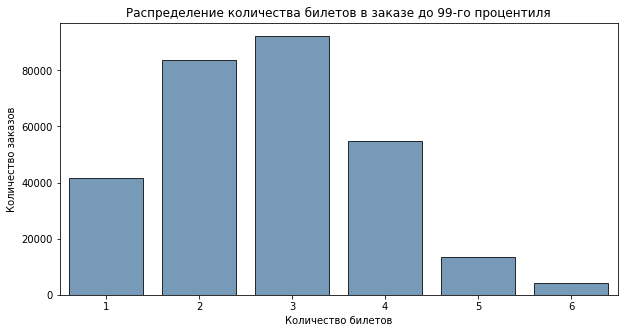

In [23]:
# Строим распределение количества билетов в заказах до 99-го процентиля
tickets_q99 = df['tickets_count'].quantile(0.99)

plt.figure(figsize=(10, 5))

sns.countplot(
    data=df[df['tickets_count'] <= tickets_q99],
    x='tickets_count',
    color='steelblue',
    edgecolor='black',       
    alpha=0.8)

# Добавляем заголовок и подписи
plt.title('Распределение количества билетов в заказе до 99-го процентиля')
plt.xlabel('Количество билетов')
plt.ylabel('Количество заказов')

# Выводим график
plt.show()

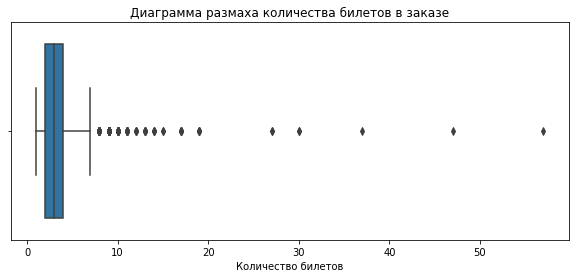

In [24]:
# Строим диаграмму размаха количества билетов
plt.figure(figsize=(10, 4))

sns.boxplot(
    data=df,
    x='tickets_count')

# Добавляем заголовок и подписи
plt.title('Диаграмма размаха количества билетов в заказе')
plt.xlabel('Количество билетов')

# Выводим график
plt.show()

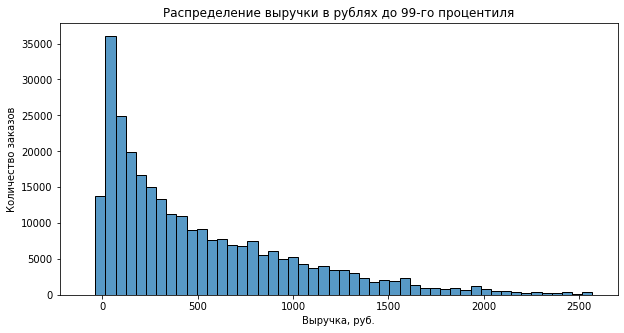

In [25]:
# Строим распределение выручки в рублях до 99-го процентиля
rub_q99 = revenue_q99['rub']

plt.figure(figsize=(10, 5))

sns.histplot(
    data=df[
        (df['currency_code'] == 'rub') &
        (df['revenue'] <= rub_q99)], x='revenue', bins=50)

# Добавляем заголовок и подписи
plt.title('Распределение выручки в рублях до 99-го процентиля')
plt.xlabel('Выручка, руб.')
plt.ylabel('Количество заказов')

# Выводим график
plt.show()

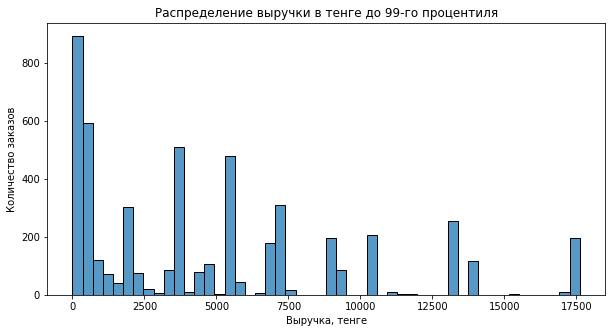

In [26]:
# Строим распределение выручки в тенге до 99-го процентиля
kzt_q99 = revenue_q99['kzt']

plt.figure(figsize=(10, 5))

sns.histplot(
    data=df[
        (df['currency_code'] == 'kzt') &
        (df['revenue'] <= kzt_q99)], x='revenue', bins=50)

# Добавляем заголовок и подписи
plt.title('Распределение выручки в тенге до 99-го процентиля')
plt.xlabel('Выручка, тенге')
plt.ylabel('Количество заказов')

# Выводим график
plt.show()

In [27]:
# Считаем количество заказов выше 99-го процентиля отдельно по валютам
rub_outliers = (
    (df['currency_code'] == 'rub') &
    (df['revenue'] > revenue_q99['rub'])).sum()

kzt_outliers = (
    (df['currency_code'] == 'kzt') &
    (df['revenue'] > revenue_q99['kzt'])).sum()

# Общее количество выбросов по всем валютам
total_outliers = rub_outliers + kzt_outliers

print('Выбросов в рублях:', rub_outliers)
print('Выбросов в тенге:', kzt_outliers)
print('Всего выбросов:', total_outliers)
print('Доля выбросов:', round(total_outliers / len(df) * 100, 2),'%')

Выбросов в рублях: 2800
Выбросов в тенге: 29
Всего выбросов: 2829
Доля выбросов: 0.97 %


In [28]:
# Считаем общее количество заказов в каждой валюте
rub_count = (df['currency_code'] == 'rub').sum()
kzt_count = (df['currency_code'] == 'kzt').sum()

# Рассчитываем долю выбросов внутри каждой валюты
rub_outliers_share = rub_outliers / rub_count * 100
kzt_outliers_share = kzt_outliers / kzt_count * 100

# Выводим результат
print('Доля выбросов в рублях:',round(rub_outliers_share, 2),'%')
print('Доля выбросов в тенге:',round(kzt_outliers_share, 2),'%')

Доля выбросов в рублях: 0.98 %
Доля выбросов в тенге: 0.57 %


In [29]:
# Количество строк до фильтрации
rows_before = len(df)

# Оставляем значения выручки не выше 99-го процентиля (для каждой валюты)
df = df[
    ((df['currency_code'] == 'rub') & (df['revenue'] <= revenue_q99['rub'])) |
    ((df['currency_code'] == 'kzt') & (df['revenue'] <= revenue_q99['kzt']))
].copy().reset_index(drop=True)

# Проверяем результат
print('Строк до фильтрации:', rows_before)
print('Строк после фильтрации:', len(df))
print('Удалено строк:', rows_before - len(df))
print('Сохранено данных:', round(len(df) / rows_before * 100, 2),'%')

Строк до фильтрации: 290611
Строк после фильтрации: 287782
Удалено строк: 2829
Сохранено данных: 99.03 %


**Промежуточный вывод:**

- Анализ количественных показателей показал, что в большинстве заказов приобретается небольшое количество билетов: медианное значение составляет 3 билета, а 99-й процентиль — 6 билетов. Только 188 заказов содержат более 6 билетов, максимальное значение составляет 57 билетов. Поскольку такие наблюдения встречаются редко и не обязательно являются ошибочными, они были сохранены.
- Распределение выручки имеет выраженную правостороннюю асимметрию, поэтому выбросы анализировались отдельно для каждой валюты. 99-й процентиль составил 2570,80 руб. для заказов в рублях и 17617,24 тенге для заказов в тенге.
- При сравнении выбросов по валютам их абсолютное количество значительно выше среди рублёвых заказов — 2800 против 29 в тенге. При этом и относительная доля выбросов выше для RUB: 0,98% против 0,57% для KZT. Различия в абсолютном количестве во многом связаны с тем, что рублёвых заказов в данных значительно больше.
- Всего было удалено 2829 наблюдений выше 99-го процентиля, что составляет 0,97% данных на данном этапе предобработки. После фильтрации осталось 287782 строки — 99,03% данных.
- Также были обнаружены нулевые и отрицательные значения выручки: в рублях — 5520 нулевых и 381 отрицательное значение, в тенге — 6 нулевых значений. Поскольку однозначных оснований считать их ошибочными нет, эти наблюдения были сохранены для дальнейшего анализа.

###  Обработка дубликатов

In [30]:
# Проверяем количество полных дубликатов
print('Количество явных дубликатов:', df.duplicated().sum())

# Формируем список столбцов без order_id
cols_no_order = [col for col in df.columns if col != 'order_id']

# Проверяем количество дубликатов без учёта order_id
dups_no_order = df.duplicated(subset=cols_no_order).sum()

print('Количество дубликатов без учёта order_id:', dups_no_order)

Количество явных дубликатов: 0
Количество дубликатов без учёта order_id: 30


In [31]:
# Выводим примеры повторяющихся бронирований
duplicate_rows = df[
    df.duplicated(
        subset=cols_no_order,
        keep=False)].sort_values(
    ['user_id', 'created_ts_msk', 'event_id'])

duplicate_rows.head(20)

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,...,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
11643,1123983,06eb7897f65b433,2024-08-13,2024-08-13 16:31:07,183706,нет,18,rub,mobile,69.82,...,69796237-909b-42a7-bfb5-c1b8574c4c76,спектакль,театр,№1482,Светополянский округ,Глиноград,54.0,4443.0,"Центр культурного наследия ""Объединение"" и пар...","бул. Карбышева, д. 50"
11644,1123867,06eb7897f65b433,2024-08-13,2024-08-13 16:31:07,183706,нет,18,rub,mobile,69.82,...,69796237-909b-42a7-bfb5-c1b8574c4c76,спектакль,театр,№1482,Светополянский округ,Глиноград,54.0,4443.0,"Центр культурного наследия ""Объединение"" и пар...","бул. Карбышева, д. 50"
56660,160922,2564e3703075008,2024-10-30,2024-10-30 10:04:15,589005,нет,6,rub,mobile,11.23,...,bee8d0cc-282b-492e-9ed8-ec0990f43ffd,выставка,другое,№1810,Яблоневская область,Горяново,11036.0,1656.0,"Модная академия ""Пункт"" Лимитед","бул. Гагарина, д. 39"
56663,160893,2564e3703075008,2024-10-30,2024-10-30 10:04:15,589005,нет,6,rub,mobile,11.23,...,bee8d0cc-282b-492e-9ed8-ec0990f43ffd,выставка,другое,№1810,Яблоневская область,Горяново,11036.0,1656.0,"Модная академия ""Пункт"" Лимитед","бул. Гагарина, д. 39"
83139,3363711,3ee7dc2e115847f,2024-06-25,2024-06-25 07:32:08,277504,нет,6,rub,mobile,59.19,...,dcb6fe75-8502-480d-b8a2-6bee187cb7ee,событие,выставки,№5015,Нежинская область,Каменёвка,76.0,3094.0,"Сообщество художников ""Палитра"" и партнеры","пр. Театральный, д. 161 стр. 2"
83144,3363798,3ee7dc2e115847f,2024-06-25,2024-06-25 07:32:08,277504,нет,6,rub,mobile,59.19,...,dcb6fe75-8502-480d-b8a2-6bee187cb7ee,событие,выставки,№5015,Нежинская область,Каменёвка,76.0,3094.0,"Сообщество художников ""Палитра"" и партнеры","пр. Театральный, д. 161 стр. 2"
146916,2324032,7b525118ae656af,2024-10-28,2024-10-28 08:33:04,588203,нет,0,rub,mobile,26.96,...,88478781-0311-42e3-b0ea-d4d6a171b70a,спорт,спорт,№1503,Чистогорская область,Песчанская,21.0,2155.0,"Клуб моделей ""Гармония"" Инк","ул. Прохладная, д. 8 к. 432"
146920,2323916,7b525118ae656af,2024-10-28,2024-10-28 08:33:04,588203,нет,0,rub,mobile,26.96,...,88478781-0311-42e3-b0ea-d4d6a171b70a,спорт,спорт,№1503,Чистогорская область,Песчанская,21.0,2155.0,"Клуб моделей ""Гармония"" Инк","ул. Прохладная, д. 8 к. 432"
152546,5372628,7eb4fc207ecc10f,2024-08-23,2024-08-23 14:08:19,298035,нет,6,rub,mobile,126.84,...,09164a56-0fb3-43c7-91d3-8ed22bb3d8ef,событие,другое,№4403,Североярская область,Озёрск,2.0,2795.0,"Клуб исторических реконструкций ""Логос"" и парт...","пр. Пушкина, д. 8/6 к. 482"
152549,5372831,7eb4fc207ecc10f,2024-08-23,2024-08-23 14:08:19,298035,нет,6,rub,mobile,126.84,...,09164a56-0fb3-43c7-91d3-8ed22bb3d8ef,событие,другое,№4403,Североярская область,Озёрск,2.0,2795.0,"Клуб исторических реконструкций ""Логос"" и парт...","пр. Пушкина, д. 8/6 к. 482"


In [32]:
# Сохраняем количество строк до удаления дубликатов
rows_before = len(df)

# Удаляем неявные дубликаты без учёта order_id
df = (df.drop_duplicates(subset=cols_no_order, keep='first').reset_index(drop=True))

# Выводим результат
print('Строк до удаления:', rows_before)
print('Строк после удаления:', len(df))
print('Удалено дубликатов:', rows_before - len(df))

Строк до удаления: 287782
Строк после удаления: 287752
Удалено дубликатов: 30


In [33]:
# Повторно проверяем данные на дубликаты
print('Полных дубликатов:', df.duplicated().sum())
print('Дубликатов без учёта order_id:',df.duplicated(subset=cols_no_order).sum())

Полных дубликатов: 0
Дубликатов без учёта order_id: 0


**Промежуточный вывод:**

- Полных дубликатов в данных не обнаружено.
- При проверке бронирований без учёта уникального идентификатора заказа `order_id` было выявлено 30 повторных записей. В выявленных строках различается только уникальный идентификатор order_id, тогда как пользователь, время оформления, мероприятие и остальные характеристики заказа полностью совпадают. Такие записи были расценены как технические повторы одного бронирования и удалены с сохранением первой записи.
- Повторные записи были удалены с сохранением первой записи каждого бронирования. После обработки в датафрейме осталось 287752 строки. Повторная проверка показала отсутствие явных и неявных дубликатов.

###  Преобразование типов данных

In [34]:
# Выводим типы данных
df.dtypes

order_id                    int64
user_id                    object
created_dt_msk             object
created_ts_msk             object
event_id                    int64
cinema_circuit             object
age_limit                   int64
currency_code              object
device_type_canonical      object
revenue                   float64
service_name               object
tickets_count               int64
total                     float64
days_since_prev           float64
event_name                 object
event_type_description     object
event_type_main            object
organizers                 object
region_name                object
city_name                  object
city_id                   float64
venue_id                  float64
venue_name                 object
venue_address              object
dtype: object

In [35]:
# Выводим типы данных таблицы с курсом тенге
tenge.dtypes

data        object
nominal      int64
curs       float64
cdx         object
dtype: object

In [36]:
# Преобразуем дату заказа в формат datetime
df['created_dt_msk'] = pd.to_datetime(df['created_dt_msk'])

# Преобразуем дату и время оформления заказа в формат datetime
df['created_ts_msk'] = pd.to_datetime(df['created_ts_msk'])

# Преобразуем дату курса тенге в формат datetime
tenge['data'] = pd.to_datetime(tenge['data'])

# Выводим результат
print('created_dt_msk:', df['created_dt_msk'].dtype)
print('created_ts_msk:', df['created_ts_msk'].dtype)
print('data:', tenge['data'].dtype)

created_dt_msk: datetime64[ns]
created_ts_msk: datetime64[ns]
data: datetime64[ns]


In [37]:
# Преобразуем данные
df['tickets_count'] = df['tickets_count'].astype('int8')
df['age_limit'] = df['age_limit'].astype('int8')
df['days_since_prev'] = df['days_since_prev'].astype('float32')

tenge['nominal'] = tenge['nominal'].astype('int16')

In [38]:
# Проверяем типы данных после преобразований
df[['created_dt_msk', 'created_ts_msk', 'age_limit', 'tickets_count',
    'revenue', 'total', 'days_since_prev']].dtypes

created_dt_msk     datetime64[ns]
created_ts_msk     datetime64[ns]
age_limit                    int8
tickets_count                int8
revenue                   float64
total                     float64
days_since_prev           float32
dtype: object

In [39]:
# Проверяем типы данных таблицы курса тенге
tenge.dtypes

data       datetime64[ns]
nominal             int16
curs              float64
cdx                object
dtype: object

In [40]:
# Оптимизируем типы числовых id
id_cols= ['order_id', 'event_id', 'city_id', 'venue_id']

for column in id_cols:
    df[column] = pd.to_numeric(
        df[column],
        downcast='integer')

# Проверяем результат
df[id_cols].dtypes

order_id    int32
event_id    int32
city_id     int32
venue_id    int16
dtype: object

**Промежуточный вывод:**

- В ходе предобработки были скорректированы типы данных. Столбцы `created_dt_msk` и `created_ts_msk` преобразованы в формат `datetime`, дата курса тенге `data` также приведена к типу `datetime`.
- Для оптимизации использования памяти без потери информации была уменьшена размерность ряда числовых столбцов. `age_limit` и `tickets_count` преобразованы в `int8`, `days_since_prev` — в `float32`, а `nominal` — в `int16`. Для числовых идентификаторов выполнено автоматическое уменьшение размерности целочисленных типов.
- Денежные показатели `revenue`, `total` и `curs` оставлены в формате `float64`, чтобы сохранить точность дальнейших расчётов.
- После преобразований типы данных соответствуют их содержанию и подходят для дальнейшего анализа.

###  Создание новых признаков

Для дальнейшего анализа приведём выручку к единой валюте — российскому рублю. Для заказов в тенге используем данные о курсе KZT к RUB на дату оформления заказа. Также рассчитаем выручку с одного билета и создадим признаки месяца и сезона оформления заказа.

In [41]:
# Проверяем уникальность дат и диапазон курса тенге
print('Количество строк:', len(tenge))
print('Количество уникальных дат:', tenge['data'].nunique())

print('Период курса:',tenge['data'].min(), '-', tenge['data'].max())
print('Период заказов:', df['created_dt_msk'].min(), '-', df['created_dt_msk'].max())

Количество строк: 357
Количество уникальных дат: 357
Период курса: 2024-01-10 00:00:00 - 2024-12-31 00:00:00
Период заказов: 2024-06-01 00:00:00 - 2024-10-31 00:00:00


In [42]:
# Проверяем наличие дубликатов дат
print('Дубликатов по дате курса:', tenge['data'].duplicated().sum())

Дубликатов по дате курса: 0


In [43]:
# Таблица курса для объединения
rates = tenge[['data', 'nominal', 'curs']].rename(columns={'data': 'created_dt_msk'})

# Присоединяем курс по дате заказа
df = df.merge(
    rates,
    on='created_dt_msk',
    how='left',
    validate='many_to_one')

# Проверяем наличие курса у заказов в тенге
print('Заказов в тенге без курса:', df.loc[df['currency_code'] == 'kzt','curs'].isna().sum())

Заказов в тенге без курса: 0


In [44]:
# Приводим выручку к российским рублям
df['revenue_rub'] = np.where(
    df['currency_code'] == 'rub',
    df['revenue'],
    df['revenue'] * df['curs'] / df['nominal'])

In [45]:
# Проверяем результат конвертации
df[['created_dt_msk', 'currency_code', 'revenue', 'nominal',
    'curs', 'revenue_rub']].groupby('currency_code').head(3)

,created_dt_msk,currency_code,revenue,nominal,curs,revenue_rub
0,2024-08-20,rub,1521.94,100,18.6972,1521.940000
1,2024-07-23,rub,289.45,100,18.3419,289.450000
2,2024-10-06,rub,1258.57,100,19.6475,1258.570000
70,2024-09-17,kzt,518.10,100,19.0125,98.503762
88,2024-09-02,kzt,347.18,100,18.9330,65.731589
95,2024-09-09,kzt,328.77,100,18.5991,61.148261


In [46]:
# Рассчитываем выручку с одного билета
df['one_ticket_revenue_rub'] = (df['revenue_rub'] / df['tickets_count'])

In [47]:
# Выделяем месяц оформления заказа
df['month'] = df['created_dt_msk'].dt.month.astype('int8')

In [48]:
# Создаём функцию для определения сезона
def get_season(month):
    if month in [12, 1, 2]:
        return 'зима'
    elif month in [3, 4, 5]:
        return 'весна'
    elif month in [6, 7, 8]:
        return 'лето'
    else:
        return 'осень'
    
# Определяем сезон для каждого заказа
df['season'] = df['month'].apply(get_season)

In [49]:
# Выводим первые 5 строк таблицы
df[['revenue', 'currency_code', 'revenue_rub', 'one_ticket_revenue_rub',
    'month', 'season']].head()

,revenue,currency_code,revenue_rub,one_ticket_revenue_rub,month,season
0,1521.94,rub,1521.94,380.4850,8,лето
1,289.45,rub,289.45,144.7250,7,лето
2,1258.57,rub,1258.57,314.6425,10,осень
3,8.49,rub,8.49,4.2450,7,лето
4,1390.41,rub,1390.41,463.4700,10,осень


In [50]:
# Проверяем распределение заказов по месяцам и сезонам
print('Месяцы:')
print(df['month'].value_counts().sort_index())

print('\nСезоны:')
print(df['season'].value_counts())

print('\nПропусков в revenue_rub:', df['revenue_rub'].isna().sum())
print('Пропусков в one_ticket_revenue_rub:', df['one_ticket_revenue_rub'].isna().sum())

Месяцы:
6     34164
7     40407
8     44550
9     69352
10    99279
Name: month, dtype: int64

Сезоны:
осень    168631
лето     119121
Name: season, dtype: int64

Пропусков в revenue_rub: 0
Пропусков в one_ticket_revenue_rub: 0


In [51]:
# Проверяем объём данных после предобработки
start_rows = len(orders)
end_rows = len(df)

print('Исходное количество заказов:', start_rows)
print('Количество строк после предобработки:', end_rows)
print('Удалено строк:', start_rows - end_rows)
print('Сохранено данных:', round(end_rows / start_rows * 100, 2),'%')

Исходное количество заказов: 290849
Количество строк после предобработки: 287752
Удалено строк: 3097
Сохранено данных: 98.94 %


**Вывод:**

- В ходе предобработки данные о заказах были объединены с информацией о мероприятиях. После объединения были исключены 238 заказов, для которых отсутствовала информация о мероприятии, так как соответствующие события не были представлены в таблице `events`.
- В данных были проверены пропуски, категориальные и количественные значения. Пропуски обнаружены только в столбце `days_since_prev` и являются ожидаемыми для первых покупок пользователей, поэтому они были сохранены.
- В категориальных признаках некорректных или дублирующих значений не обнаружено. При анализе количественных показателей были выявлены выбросы выручки. В соответствии с условиями проекта значения выше 99-го процентиля были удалены отдельно для рублей и тенге. Всего было исключено 2829 таких наблюдений.
- Полных дубликатов обнаружено не было. При проверке бронирований без учёта `order_id` было выявлено и удалено 30 неявных дубликатов.
- Столбцы с датами и временем были приведены к формату `datetime`, а для части числовых признаков уменьшена размерность типов данных без потери информации.
- Для дальнейшего анализа были созданы новые признаки:
   - `revenue_rub` — выручка, приведённая к российским рублям
   - `one_ticket_revenue_rub` — выручка с одного проданного билета
   - `month` — месяц оформления заказа
   - `season` — сезон оформления заказа
- После предобработки в датафрейме осталось 287752 строки, что составляет около 98,94% исходных данных. Данные подготовлены для дальнейшего исследовательского анализа.

##  Исследовательский анализ данных


###  Анализ распределения заказов по сегментам и их сезонные изменения

####  Динамика количества заказов по месяцам

In [52]:
# Считаем количество заказов по месяцам
orders_by_month = (
    df.groupby('month')['order_id']
    .nunique().reset_index(name='orders_count'))

orders_by_month

,month,orders_count
0,6,34164
1,7,40407
2,8,44550
3,9,69352
4,10,99279


In [53]:
# Добавляем названия месяцев
month_names = {
    6: 'Июнь',
    7: 'Июль',
    8: 'Август',
    9: 'Сентябрь',
    10: 'Октябрь'}

orders_by_month['month_name'] = (orders_by_month['month'].map(month_names))

orders_by_month

,month,orders_count,month_name
0,6,34164,Июнь
1,7,40407,Июль
2,8,44550,Август
3,9,69352,Сентябрь
4,10,99279,Октябрь


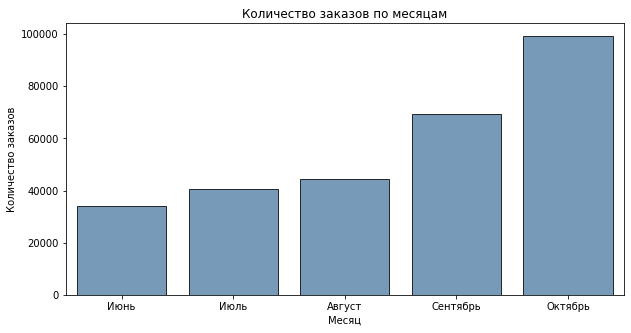

In [54]:
# Строим график количества заказов по месяцам
plt.figure(figsize=(10, 5))

sns.barplot(
    data=orders_by_month,
    x='month_name',
    y='orders_count',
    color='steelblue',         
    edgecolor='black',         
    alpha=0.8)

# Добавляем заголовок и подписи
plt.title('Количество заказов по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Количество заказов')

# Выводим график
plt.show()

In [55]:
# Считаем изменение количества заказов относительно предыдущего месяца
orders_by_month['change_pct'] = (orders_by_month['orders_count'].pct_change() * 100)

orders_by_month

,month,orders_count,month_name,change_pct
0,6,34164,Июнь,NaN
1,7,40407,Июль,18.273621
2,8,44550,Август,10.253174
3,9,69352,Сентябрь,55.672278
4,10,99279,Октябрь,43.152324


**Промежуточный вывод:**

- Количество заказов последовательно увеличивалось на протяжении всего рассматриваемого периода.
- В июне было оформлено 34164 заказа, в июле — 40407, а в августе — 44550. Летом рост был относительно умеренным (в июле количество заказов увеличилось на 18,3% по сравнению с июнем, а в августе — ещё на 10,3%).
- С наступлением осени рост заметно ускорился. В сентябре количество заказов составило 69352, что на 55,7% больше, чем в августе. В октябре показатель увеличился ещё на 43,2% и достиг 99279 заказов.
- Таким образом, с июня по октябрь количество заказов выросло примерно в 2,9 раза. Особенно выраженный рост количества заказов наблюдается с начала осеннего периода.

#### 6.1.2. Сравнение структуры заказов летом и осенью

Сравним структуру заказов летом и осенью по типам мероприятий, типам устройств и возрастным ограничениям. Поскольку количество заказов в сезонах различается, для корректного сравнения будем использовать доли заказов внутри каждого сезона.

In [56]:
# Считаем количество заказов по типам мероприятий и сезонам
event_season = (
    df.groupby(['season', 'event_type_main'])['order_id']
    .nunique().reset_index(name='orders_count'))

# Рассчитываем долю каждого типа мероприятия внутри сезона
event_season['share'] = (
    event_season['orders_count'] / event_season.groupby('season')['orders_count'].transform('sum'))

event_season

,season,event_type_main,orders_count,share
0,лето,выставки,2416,0.020282
1,лето,другое,32369,0.271732
2,лето,концерты,50768,0.426188
3,лето,спорт,3006,0.025235
4,лето,стендап,6346,0.053274
5,лето,театр,23943,0.200997
6,лето,ёлки,273,0.002292
7,осень,выставки,2436,0.014446
8,осень,другое,33225,0.197028
9,осень,концерты,62740,0.372055


In [57]:
# Переводим доли в проценты
event_season['share_pct'] = event_season['share'] * 100

event_season

,season,event_type_main,orders_count,share,share_pct
0,лето,выставки,2416,0.020282,2.028190
1,лето,другое,32369,0.271732,27.173210
2,лето,концерты,50768,0.426188,42.618850
3,лето,спорт,3006,0.025235,2.523485
4,лето,стендап,6346,0.053274,5.327356
5,лето,театр,23943,0.200997,20.099731
6,лето,ёлки,273,0.002292,0.229179
7,осень,выставки,2436,0.014446,1.444574
8,осень,другое,33225,0.197028,19.702783
9,осень,концерты,62740,0.372055,37.205496


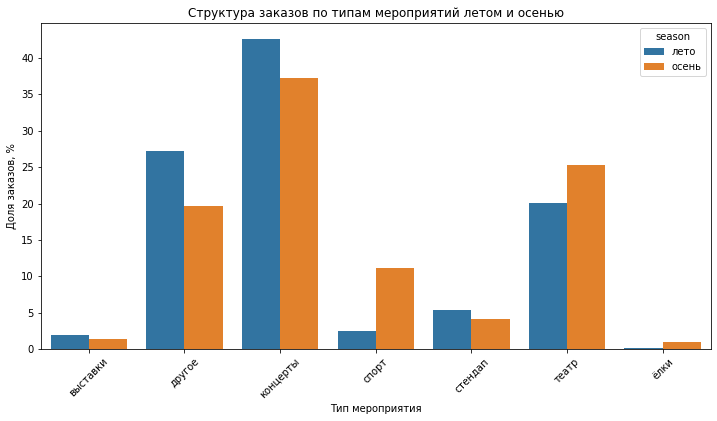

In [58]:
# Задаём размер графика и фигуру
plt.figure(figsize=(12, 6))

sns.barplot(
    data=event_season,
    x='event_type_main',
    y='share_pct',
    hue='season')

# Добавляем заголовок и подписи 
plt.title('Структура заказов по типам мероприятий летом и осенью')
plt.xlabel('Тип мероприятия')
plt.ylabel('Доля заказов, %')
plt.xticks(rotation=45)

# Выводим график
plt.show()

In [59]:
# Считаем количество заказов по типам устройств и сезонам
device_season = (
    df.groupby(['season', 'device_type_canonical'])['order_id']
    .nunique().reset_index(name='orders_count'))

# Рассчитываем долю каждого типа устройства внутри сезона
device_season['share_pct'] = (
    device_season['orders_count'] /
    device_season.groupby('season')['orders_count'].transform('sum')* 100)

# Выводим результат
device_season

,season,device_type_canonical,orders_count,share_pct
0,лето,desktop,23060,19.358467
1,лето,mobile,96061,80.641533
2,осень,desktop,34303,20.342049
3,осень,mobile,134328,79.657951


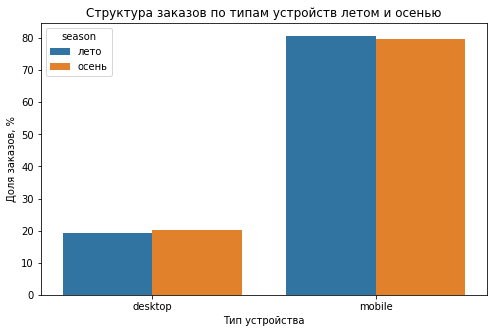

In [60]:
# Задаём размер графика и фигуру
plt.figure(figsize=(8, 5))

sns.barplot(
    data=device_season,
    x='device_type_canonical',
    y='share_pct',
    hue='season')

# Добавляем заголовок и подписи
plt.title('Структура заказов по типам устройств летом и осенью')
plt.xlabel('Тип устройства')
plt.ylabel('Доля заказов, %')

# Выводим график
plt.show()

In [61]:
# Считаем количество заказов по возрастным ограничениям и сезонам
age_season = (
    df.groupby(['season', 'age_limit'])['order_id']
    .nunique().reset_index(name='orders_count'))

# Рассчитываем долю каждой возрастной категории внутри сезона
age_season['share_pct'] = (
    age_season['orders_count'] / age_season.groupby('season')['orders_count'].transform('sum') * 100)

# Выводим результат
age_season

,season,age_limit,orders_count,share_pct
0,лето,0,21404,17.968284
1,лето,6,21673,18.194105
2,лето,12,24464,20.537101
3,лето,16,33756,28.337573
4,лето,18,17824,14.962937
5,осень,0,39828,23.618433
6,осень,6,29720,17.624280
7,осень,12,37263,22.097361
8,осень,16,44217,26.221157
9,осень,18,17603,10.438769


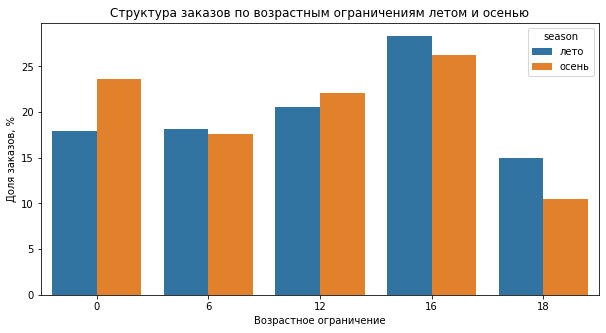

In [62]:
# Задаём размер графика и фигуру
plt.figure(figsize=(10, 5))

sns.barplot(
    data=age_season,
    x='age_limit',
    y='share_pct',
    hue='season')

# Добавляем заголовок и подписи
plt.title('Структура заказов по возрастным ограничениям летом и осенью')
plt.xlabel('Возрастное ограничение')
plt.ylabel('Доля заказов, %')

# Выводим график
plt.show()

**Промежуточный вывод:**

- Количество заказов последовательно увеличивалось с июня по октябрь 2024 года. Летом темпы роста были относительно умеренными: в июле количество заказов выросло на 18,3% по сравнению с июнем, а в августе — ещё на 10,3%. С наступлением осени рост ускорился: в сентябре количество заказов увеличилось на 55,7% относительно августа, а в октябре — ещё на 43,2%. В результате количество заказов в октябре было примерно в 2,9 раза выше, чем в июне. Поскольку летний период включает три месяца, а осенний — два, для сравнения структуры спроса использовались доли заказов внутри каждого сезона, а не абсолютные значения.
- Концерты сохранили позицию самой популярной категории, однако их доля снизилась с 42,6% летом до 37,2% осенью. Также сократилась доля категории "другое" — с 27,2% до 19,7%. Одновременно выросла доля театральных мероприятий с 20,1% до 25,3%, а наиболее заметный рост произошёл в категории "спорт" — с 2,5% до 11,2%. Доли стендапа и выставок немного снизились — с 5,3% до 4,1% и с 2,0% до 1,4% соответственно. Доля ёлок выросла с 0,2% до 1,0%, однако эта категория по-прежнему занимает небольшую часть заказов.
- Структура заказов по типам устройств практически не изменилась. Около 80% заказов в оба сезона оформлялись с мобильных устройств: 80,6% летом и 79,7% осенью. Доля заказов с desktop увеличилась незначительно — с 19,4% до 20,3%. Следовательно, осенний рост количества заказов происходил без существенного изменения структуры заказов по типам устройств.
- В разрезе возрастных ограничений осенью выросла доля заказов на мероприятия категорий 0+ и 12+: с 18,0% до 23,6% и с 20,5% до 22,1% соответственно. При этом доля категории 16+ снизилась с 28,3% до 26,2%, а наиболее заметное снижение наблюдалось в категории 18+ — с 15,0% до 10,4%. Доля мероприятий 6+ практически не изменилась.
- Таким образом, осенний период характеризуется не только более высоким количеством заказов, но и изменением структуры спроса. Увеличилась относительная доля спортивных и театральных мероприятий, а также мероприятий категорий 0+ и 12+, тогда как структура заказов по типам устройств осталась практически стабильной.

####  Изменение средней выручки с одного билета

Изучим, как изменилась средняя выручка с продажи одного билета для разных типов мероприятий летом и осенью. Для каждого типа мероприятия рассчитаем среднее значение, сравним летние и осенние значения и определим относительное изменение показателя осенью по сравнению с летом.

In [63]:
# Считаем среднюю выручку с одного билета
ticket_revenue = (
    df.groupby(['event_type_main', 'season'])['one_ticket_revenue_rub']
    .mean().reset_index(name='mean_ticket_revenue'))

# Выводим результат
ticket_revenue

,event_type_main,season,mean_ticket_revenue
0,выставки,лето,86.416198
1,выставки,осень,90.603610
2,другое,лето,77.433968
3,другое,осень,76.115334
4,концерты,лето,304.790309
5,концерты,осень,268.358737
6,спорт,лето,50.761831
7,спорт,осень,49.969733
8,стендап,лето,218.518107
9,стендап,осень,231.124973


In [64]:
# Для сравнения летних и осенних значений
ticket_revenue_pivot = (
    ticket_revenue.pivot(
        index='event_type_main',
        columns='season',
        values='mean_ticket_revenue').reset_index())

# Выводим результат
ticket_revenue_pivot

season,event_type_main,лето,осень
0,выставки,86.416198,90.603610
1,другое,77.433968,76.115334
2,концерты,304.790309,268.358737
3,спорт,50.761831,49.969733
4,стендап,218.518107,231.124973
5,театр,214.138855,175.969508
6,ёлки,271.436176,229.585589


In [65]:
# Считаем относительное изменение средней выручки с одного билета осенью относительно лета
ticket_revenue_pivot['change_pct'] = (
    (ticket_revenue_pivot['осень']- ticket_revenue_pivot['лето'])
    / ticket_revenue_pivot['лето']* 100)

# Округляем значения 
ticket_revenue_pivot[
    ['лето', 'осень', 'change_pct']] = ticket_revenue_pivot[
    ['лето', 'осень', 'change_pct']].round(2)

# Выводим результат
ticket_revenue_pivot

season,event_type_main,лето,осень,change_pct
0,выставки,86.42,90.60,4.85
1,другое,77.43,76.12,-1.70
2,концерты,304.79,268.36,-11.95
3,спорт,50.76,49.97,-1.56
4,стендап,218.52,231.12,5.77
5,театр,214.14,175.97,-17.82
6,ёлки,271.44,229.59,-15.42


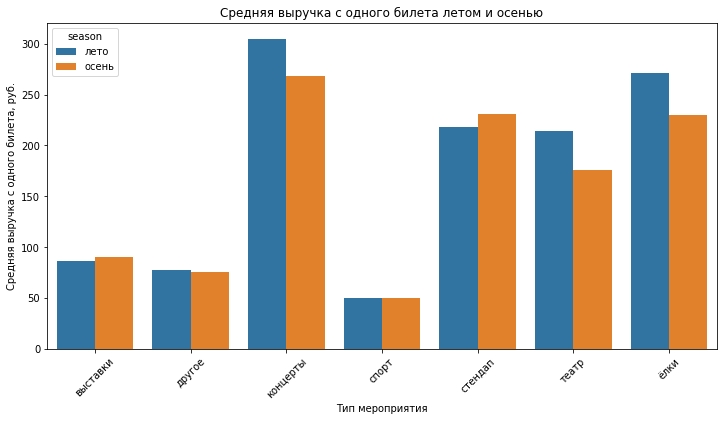

In [66]:
# Задаём размер графика и фигуру
plt.figure(figsize=(12, 6))

sns.barplot(
    data=ticket_revenue,
    x='event_type_main',
    y='mean_ticket_revenue',
    hue='season')

# Добавляем заголовок и подписи
plt.title('Средняя выручка с одного билета летом и осенью')
plt.xlabel('Тип мероприятия')
plt.ylabel('Средняя выручка с одного билета, руб.')
plt.xticks(rotation=45)

# Выводим график
plt.show()

**Вывод:**

- Осенью средняя выручка с одного билета изменилась неодинаково для разных типов мероприятий. В большинстве категорий показатель снизился, а рост наблюдался только для стендапа и выставок.
- Самая высокая средняя выручка с одного билета в оба сезона характерна для концертов: она снизилась с 304,79 руб. летом до 268,36 руб. осенью, или на 11,95%.
- Наиболее заметное снижение произошло в театре — на 17,82%, а также в категории "ёлки" — на 15,42%. Для категорий "другое" и "спорт" изменения были незначительными.
- Рост показателя наблюдался для стендапа — на 5,77% и для выставок — на 4,85%.
- Таким образом, на фоне роста количества заказов осенью средняя выручка с одного билета для большинства типов мероприятий снизилась. Наиболее выраженное снижение наблюдалось для театра, ёлок и концертов, тогда как стендап и выставки показали умеренный рост.

### Осенняя активность пользователей

####  Динамика пользовательской активности по дням

In [67]:
# Отбираем данные только за осенний период
autumn_df = df[df['season'] == 'осень'].copy()

# Выводим результат
print('Период:', autumn_df['created_dt_msk'].min(), '-', autumn_df['created_dt_msk'].max())
print('Количество строк:', len(autumn_df))

Период: 2024-09-01 00:00:00 - 2024-10-31 00:00:00
Количество строк: 168631


In [68]:
# Рассчитываем ежедневные показатели пользовательской активности
daily_activity = (
    autumn_df.groupby('created_dt_msk').agg(
        orders_count=('order_id', 'nunique'),
        dau=('user_id', 'nunique'),
        mean_ticket_revenue=('one_ticket_revenue_rub', 'mean')).reset_index())

# Рассчитываем среднее количество заказов на одного активного пользователя
daily_activity['orders_per_user'] = (daily_activity['orders_count'] / daily_activity['dau'])

# Выводим первые 5 строк
daily_activity.head()

,created_dt_msk,orders_count,dau,mean_ticket_revenue,orders_per_user
0,2024-09-01,1327,564,200.168708,2.352837
1,2024-09-02,1380,574,189.464639,2.404181
2,2024-09-03,5113,778,80.350151,6.571979
3,2024-09-04,1773,686,178.048069,2.584548
4,2024-09-05,1944,739,189.510156,2.630582


In [69]:
# Выводим описательную статистику ежедневных показателей
daily_activity[['orders_count', 'dau', 'orders_per_user', 'mean_ticket_revenue']].describe()

,orders_count,dau,orders_per_user,mean_ticket_revenue
count,61.000000,61.000000,61.000000,61.000000
mean,2764.442623,923.590164,2.956928,183.241225
std,967.855112,143.335548,0.757860,21.782807
min,1327.000000,564.000000,2.327806,80.350151
25%,2314.000000,822.000000,2.703143,178.048069
50%,2650.000000,946.000000,2.780693,186.968328
75%,2910.000000,1025.000000,2.915334,196.208589
max,7289.000000,1272.000000,6.632393,209.375782


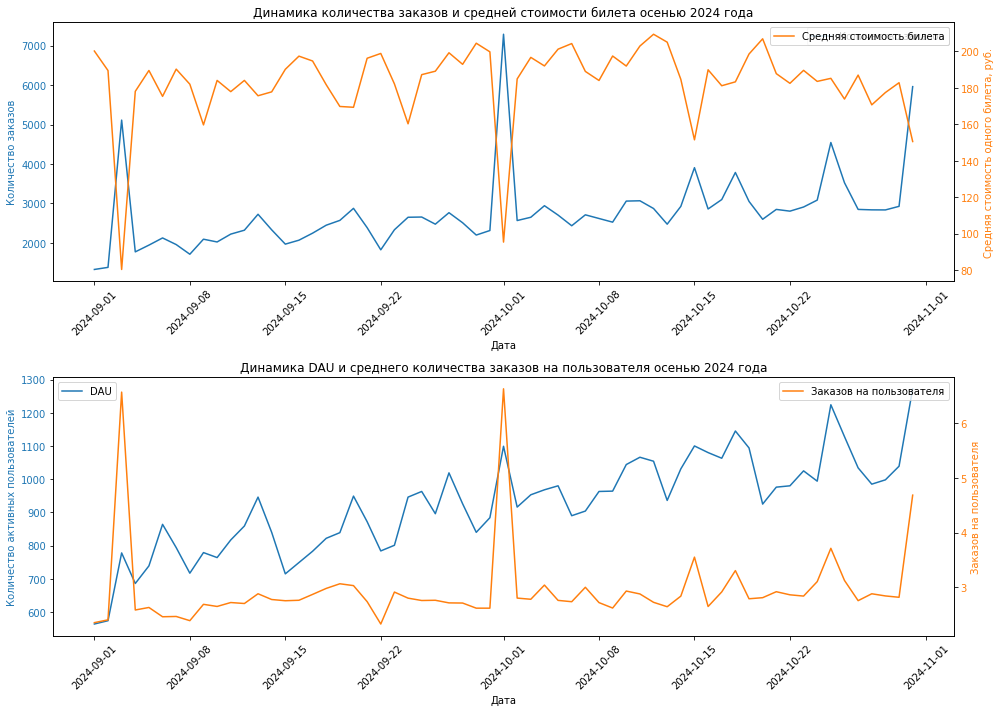

In [70]:
# Создаём фигуру с двумя графиками
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# 1. Количество заказов и средняя стоимость билета
ax1 = axes[0]

sns.lineplot(
    data=daily_activity,
    x='created_dt_msk',
    y='orders_count',
    ax=ax1,
    color='tab:blue',
    label='Количество заказов')

ax1_right = ax1.twinx()

sns.lineplot(
    data=daily_activity,
    x='created_dt_msk',
    y='mean_ticket_revenue',
    ax=ax1_right,
    color='tab:orange',
    label='Средняя стоимость билета')

ax1.set_title('Динамика количества заказов и средней стоимости билета осенью 2024 года')
ax1.set_xlabel('Дата')
ax1.set_ylabel('Количество заказов', color='tab:blue')
ax1_right.set_ylabel('Средняя стоимость одного билета, руб.', color='tab:orange')

ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1_right.tick_params(axis='y', labelcolor='tab:orange')
ax1.tick_params(axis='x', rotation=45)


# 2. DAU и среднее количество заказов на пользователя
ax2 = axes[1]

sns.lineplot(
    data=daily_activity,
    x='created_dt_msk',
    y='dau',
    ax=ax2,
    color='tab:blue',
    label='DAU')

ax2_right = ax2.twinx()

sns.lineplot(
    data=daily_activity,
    x='created_dt_msk',
    y='orders_per_user',
    ax=ax2_right,
    color='tab:orange',
    label='Заказов на пользователя')

ax2.set_title('Динамика DAU и среднего количества заказов на пользователя осенью 2024 года')
ax2.set_xlabel('Дата')
ax2.set_ylabel('Количество активных пользователей', color='tab:blue')
ax2_right.set_ylabel('Заказов на пользователя', color='tab:orange')

ax2.tick_params(axis='y', labelcolor='tab:blue')
ax2_right.tick_params(axis='y', labelcolor='tab:orange')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

####  Недельная цикличность пользовательской активности

Выделим день недели и сравним пользовательскую активность в будни и выходные.

In [106]:
# Добавляем номер дня недели
daily_activity['weekday_num'] = daily_activity['created_dt_msk'].dt.dayofweek

# Создаём названия дней недели
weekday_names = {
    0: 'Понедельник',
    1: 'Вторник',
    2: 'Среда',
    3: 'Четверг',
    4: 'Пятница',
    5: 'Суббота',
    6: 'Воскресенье'}

daily_activity['weekday'] = (daily_activity['weekday_num'].map(weekday_names))

# Разделяем дни на будни и выходные
daily_activity['day_type'] = np.where(
    daily_activity['weekday_num'] < 5,
    'будни',
    'выходные')

In [72]:
# Определяем аномально высокие дни по количеству заказов методом IQR
q1 = daily_activity['orders_count'].quantile(0.25)
q3 = daily_activity['orders_count'].quantile(0.75)
iqr = q3 - q1

upper_bound = q3 + 1.5 * iqr

print('Верхняя граница количества заказов:', round(upper_bound, 2))

# Выводим дни с аномально высоким количеством заказов
anomalous_days = daily_activity.loc[daily_activity['orders_count'] > upper_bound,
    ['created_dt_msk','weekday','orders_count','dau','orders_per_user','mean_ticket_revenue']].copy()

anomalous_days

Верхняя граница количества заказов: 3804.0


,created_dt_msk,weekday,orders_count,dau,orders_per_user,mean_ticket_revenue
2,2024-09-03,Вторник,5113,778,6.571979,80.350151
30,2024-10-01,Вторник,7289,1099,6.632393,95.364485
44,2024-10-15,Вторник,3907,1100,3.551818,151.464117
54,2024-10-25,Пятница,4545,1224,3.713235,185.186946
60,2024-10-31,Четверг,5961,1272,4.686321,150.530017


In [73]:
# Исключаем аномально высокие дни только из анализа недельной цикличности
daily_activity_clean = daily_activity[daily_activity['orders_count'] <= upper_bound].copy()

print('Дней до фильтрации:', len(daily_activity))
print('Дней после фильтрации:', len(daily_activity_clean))
print('Исключено дней:', len(daily_activity) - len(daily_activity_clean))

Дней до фильтрации: 61
Дней после фильтрации: 56
Исключено дней: 5


In [74]:
# Рассчитываем средние показатели по дням недели без аномально высоких дней
weekday_activity_clean = (daily_activity_clean.groupby(['weekday_num', 'weekday'])
    .agg(
        mean_orders=('orders_count', 'mean'),
        mean_dau=('dau', 'mean'),
        mean_orders_per_user=('orders_per_user', 'mean'),
        mean_ticket_revenue=('mean_ticket_revenue', 'mean'))
    .reset_index()
    .sort_values('weekday_num'))

# Округляем значения
weekday_activity_clean[
    ['mean_orders','mean_dau','mean_orders_per_user','mean_ticket_revenue']] = weekday_activity_clean[
    ['mean_orders','mean_dau','mean_orders_per_user','mean_ticket_revenue']].round(2)

weekday_activity_clean

,weekday_num,weekday,mean_orders,mean_dau,mean_orders_per_user,mean_ticket_revenue
0,0,Понедельник,2390.56,853.67,2.78,184.49
1,1,Вторник,2530.17,905.67,2.79,180.48
2,2,Среда,2543.44,923.56,2.75,185.49
3,3,Четверг,2650.75,923.38,2.86,185.71
4,4,Пятница,2898.57,993.86,2.90,185.38
5,5,Суббота,2667.75,961.00,2.76,192.50
6,6,Воскресенье,2154.56,822.78,2.60,197.64


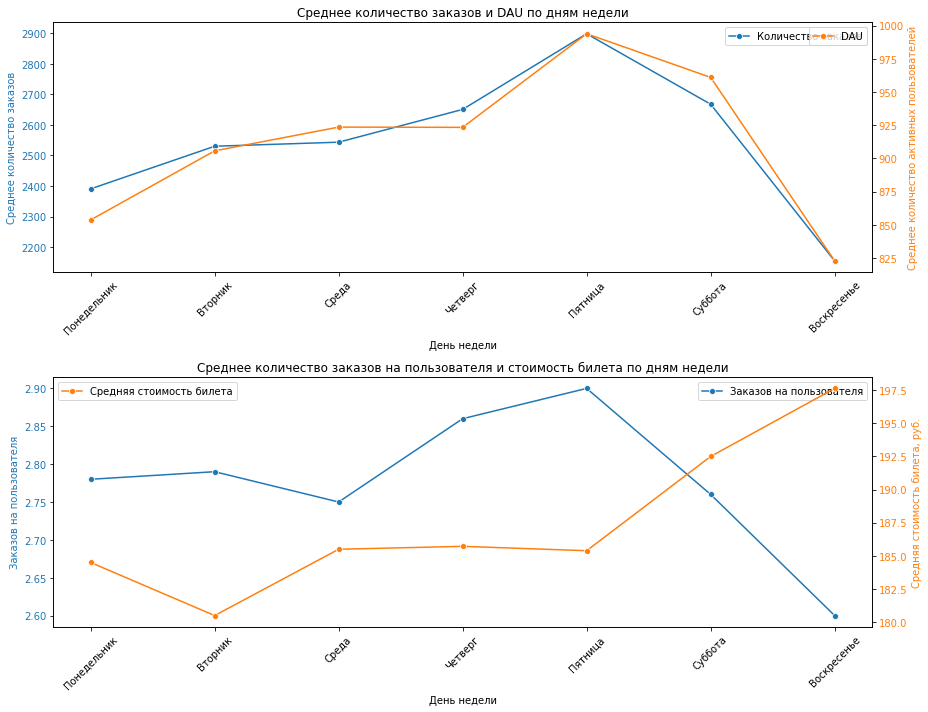

In [75]:
# Создаём фигуру с двумя графиками
fig, axes = plt.subplots(2, 1, figsize=(13, 10))

# 1. Среднее количество заказов и DAU по дням недели
ax1 = axes[0]

sns.lineplot(
    data=weekday_activity_clean,
    x='weekday',
    y='mean_orders',
    marker='o',
    color='tab:blue',
    label='Количество заказов',
    ax=ax1)

ax1_right = ax1.twinx()

sns.lineplot(
    data=weekday_activity_clean,
    x='weekday',
    y='mean_dau',
    marker='o',
    color='tab:orange',
    label='DAU',
    ax=ax1_right
)

ax1.set_title('Среднее количество заказов и DAU по дням недели')
ax1.set_xlabel('День недели')
ax1.set_ylabel('Среднее количество заказов', color='tab:blue')
ax1_right.set_ylabel('Среднее количество активных пользователей', color='tab:orange')

ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1_right.tick_params(axis='y', labelcolor='tab:orange')
ax1.tick_params(axis='x', rotation=45)


# 2. Заказы на пользователя и средняя стоимость билета
ax2 = axes[1]

sns.lineplot(
    data=weekday_activity_clean,
    x='weekday',
    y='mean_orders_per_user',
    marker='o',
    color='tab:blue',
    label='Заказов на пользователя',
    ax=ax2)

ax2_right = ax2.twinx()

sns.lineplot(
    data=weekday_activity_clean,
    x='weekday',
    y='mean_ticket_revenue',
    marker='o',
    color='tab:orange',
    label='Средняя стоимость билета',
    ax=ax2_right)

ax2.set_title('Среднее количество заказов на пользователя и стоимость билета по дням недели')
ax2.set_xlabel('День недели')
ax2.set_ylabel('Заказов на пользователя', color='tab:blue')
ax2_right.set_ylabel('Средняя стоимость билета, руб.', color='tab:orange')

ax2.tick_params(axis='y', labelcolor='tab:blue')
ax2_right.tick_params(axis='y', labelcolor='tab:orange')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [76]:
# Сравниваем показатели в будни и выходные
day_type_activity_clean = (daily_activity_clean.groupby('day_type').agg(
        mean_orders=('orders_count', 'mean'),
        mean_dau=('dau', 'mean'),
        mean_orders_per_user=('orders_per_user', 'mean'),
        mean_ticket_revenue=('mean_ticket_revenue', 'mean')).round(2).reset_index())

day_type_activity_clean

,day_type,mean_orders,mean_dau,mean_orders_per_user,mean_ticket_revenue
0,будни,2591.87,917.26,2.81,184.51
1,выходные,2396.06,887.82,2.68,195.22


In [77]:
# Добавляем месяц для анализа изменения активности осенью
daily_activity_clean['month'] = (
    daily_activity_clean['created_dt_msk'].dt.month)

# Сравниваем средние дневные показатели сентября и октября
monthly_activity = (daily_activity_clean.groupby('month').agg(
        mean_orders=('orders_count', 'mean'),
        mean_dau=('dau', 'mean'),
        mean_orders_per_user=('orders_per_user', 'mean')).round(2))

# Переименовываем месяцы
monthly_activity.index = monthly_activity.index.map({
    9: 'Сентябрь',
    10: 'Октябрь'})

monthly_activity

,mean_orders,mean_dau,mean_orders_per_user
month,,,
Сентябрь,2215.14,818.31,2.69
Октябрь,2873.22,1005.00,2.86


In [78]:
# Рассчитываем изменение показателей в октябре относительно сентября
autumn_change = (
    (monthly_activity.loc['Октябрь'] /
     monthly_activity.loc['Сентябрь'] - 1) * 100).round(2)

autumn_change

mean_orders             29.71
mean_dau                22.81
mean_orders_per_user     6.32
dtype: float64

**Промежуточный вывод:**

- При анализе дневной активности были обнаружены 5 дней с аномально высоким количеством заказов. Три из них пришлись на вторник, в том числе 3 сентября и 1 октября, когда количество заказов превышало 5 тыс. Эти значения заметно завышали средний показатель вторника, поэтому для дополнительного анализа недельной цикличности аномальные дни были исключены. При этом из исходных данных они не удалялись.
- После исключения аномальных дней недельная цикличность стала более выраженной: среднее количество заказов в целом увеличивается от понедельника к пятнице — с 2391 до 2899 заказов, после чего снижается в выходные. Максимальный средний DAU также наблюдается в пятницу — около 994 пользователей.
- В будние дни в среднем оформляется 2592 заказа против 2396 в выходные. Разница связана как с большим числом активных пользователей в будни — 917 против 888, так и с более высоким количеством заказов на пользователя — 2,81 против 2,68.
- Средняя стоимость одного билета, напротив, выше в выходные: около 195 руб. против 185 руб. в будние дни.
- С сентября по октябрь среднее дневное количество заказов выросло на 29,7%. При этом DAU увеличился на 22,8%, а среднее количество заказов на пользователя — на 6,3%. Таким образом, рост количества заказов происходит за счёт обоих факторов, но основной вклад связан с увеличением числа активных пользователей.
- В целом после исключения экстремальных дней наблюдается устойчивая недельная цикличность: активность возрастает к концу рабочей недели и снижается в выходные, тогда как средняя стоимость билета в выходные становится выше.

###  Популярные события и партнёры

Изучим распределение мероприятий и заказов по регионам и билетным партнёрам.

####  Распределение мероприятий и заказов по регионам

In [79]:
# Рассчитываем количество уникальных мероприятий и заказов по регионам
region_stats = (df.groupby('region_name').agg(events_count=('event_id', 'nunique'),
        orders_count=('order_id', 'nunique')).reset_index())

# Выводим первые 5 строк
region_stats.head()

,region_name,events_count,orders_count
0,Белоярская область,57,199
1,Берестовский округ,39,393
2,Берёзовская область,166,1282
3,Боровлянский край,97,1721
4,Верховинская область,7,45


In [80]:
# Рассчитываем долю мероприятий и заказов каждого региона
total_events = df['event_id'].nunique()
total_orders = df['order_id'].nunique()

region_stats['events_share_pct'] = (region_stats['events_count'] / total_events * 100)

region_stats['orders_share_pct'] = (region_stats['orders_count'] / total_orders * 100)

# Округляем доли
region_stats[['events_share_pct', 'orders_share_pct']] = region_stats[
    ['events_share_pct', 'orders_share_pct']].round(2)

# Выводим первые 5 строк
region_stats.head()

,region_name,events_count,orders_count,events_share_pct,orders_share_pct
0,Белоярская область,57,199,0.25,0.07
1,Берестовский округ,39,393,0.17,0.14
2,Берёзовская область,166,1282,0.74,0.45
3,Боровлянский край,97,1721,0.43,0.60
4,Верховинская область,7,45,0.03,0.02


In [81]:
# Выводим топ-10 регионов по количеству уникальных мероприятий
top_regions_events = (region_stats.sort_values('events_count', ascending=False).head(10))

# Выводим результат
top_regions_events

,region_name,events_count,orders_count,events_share_pct,orders_share_pct
23,Каменевский регион,5935,89665,26.54,31.16
60,Североярская область,3800,43739,17.00,15.20
77,Широковская область,1232,16169,5.51,5.62
57,Светополянский округ,1075,7502,4.81,2.61
52,Речиновская область,702,6267,3.14,2.18
74,Травяная область,683,5036,3.05,1.75
11,Горицветская область,551,5153,2.46,1.79
61,Серебринская область,541,5586,2.42,1.94
78,Яблоневская область,535,6123,2.39,2.13
69,Тепляковская область,528,4384,2.36,1.52


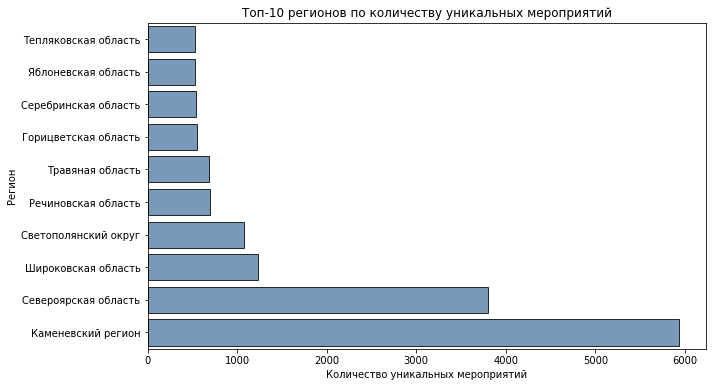

In [82]:
# Сортируем данные 
top_regions_events_plot = (top_regions_events.sort_values('events_count'))

# Задаём размер графика и фигуру
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_regions_events_plot,
    y='region_name',
    x='events_count',
    color='steelblue',          
    edgecolor='black',          
    alpha=0.8)                  

# Добавляем заголовок и подписи
plt.title('Топ-10 регионов по количеству уникальных мероприятий')
plt.xlabel('Количество уникальных мероприятий')
plt.ylabel('Регион')

# Выводим график
plt.show()

In [83]:
# Выводим топ-10 регионов по количеству заказов
top_regions_orders = (region_stats.sort_values('orders_count', ascending=False).head(10))

# Выводим результат
top_regions_orders

,region_name,events_count,orders_count,events_share_pct,orders_share_pct
23,Каменевский регион,5935,89665,26.54,31.16
60,Североярская область,3800,43739,17.00,15.20
77,Широковская область,1232,16169,5.51,5.62
42,Медовская область,504,13892,2.25,4.83
45,Озернинский край,349,10405,1.56,3.62
57,Светополянский округ,1075,7502,4.81,2.61
41,Малиновоярский округ,165,6314,0.74,2.19
64,Солнечноземская область,522,6278,2.33,2.18
52,Речиновская область,702,6267,3.14,2.18
78,Яблоневская область,535,6123,2.39,2.13


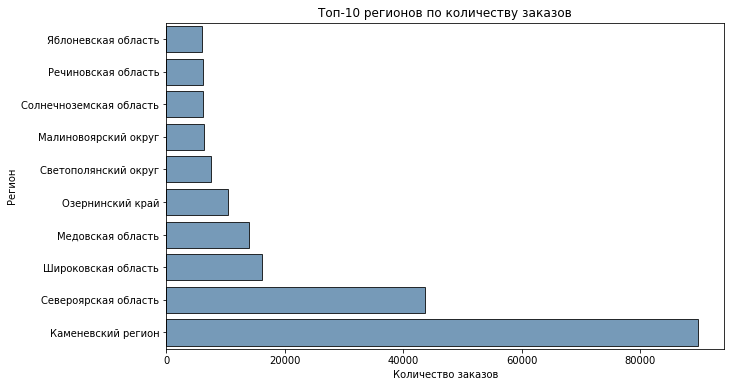

In [84]:
# Сортируем данные
top_regions_orders_plot = (top_regions_orders.sort_values('orders_count'))

# Задаём размер графика и фигуру
plt.figure(figsize=(10, 6))

# Строим диаграмму количества заказов
sns.barplot(
    data=top_regions_orders_plot,
    y='region_name',
    x='orders_count',
    color='steelblue',          
    edgecolor='black',          
    alpha=0.8)

# Добавляем заголовок и подписи
plt.title('Топ-10 регионов по количеству заказов')
plt.xlabel('Количество заказов')
plt.ylabel('Регион')

# Выводим график
plt.show()

In [85]:
# Cчитываем долю показателей (топ-10 регионов)
top10_events_share = (top_regions_events['events_count'].sum()/ total_events * 100)
top10_orders_share = (top_regions_orders['orders_count'].sum()/ total_orders * 100)

print('Доля мероприятий в топ-10 регионах:',round(top10_events_share, 2),'%')
print('Доля заказов в топ-10 регионах:',round(top10_orders_share, 2),'%')

Доля мероприятий в топ-10 регионах: 69.69 %
Доля заказов в топ-10 регионах: 71.71 %


####  Анализ билетных партнёров

In [86]:
# Рассчитываем количество уникальных мероприятий по билетным партнёрам
partner_stats = (df.groupby('service_name') .agg(events_count=('event_id', 'nunique'),
    orders_count=('order_id', 'nunique'),revenue_rub=('revenue_rub', 'sum')).reset_index())

# Выводим первые 5 строк
partner_stats.head()

,service_name,events_count,orders_count,revenue_rub
0,Crazy ticket!,256,789,4.519248e+05
1,Show_ticket,295,2090,1.449276e+06
2,Билет по телефону,20,85,7.244740e+04
3,Билеты без проблем,4247,62858,2.432219e+07
4,Билеты в интернете,1,4,5.482300e+02


In [87]:
# Считаем общее количество заказов и суммарную выручку
total_orders = df['order_id'].nunique()
total_revenue = df['revenue_rub'].sum()

# Считываем доли партнёров
partner_stats['orders_share_pct'] = (partner_stats['orders_count'] / total_orders * 100)

partner_stats['revenue_share_pct'] = ( partner_stats['revenue_rub'] / total_revenue * 100)

# Округляем показатели
partner_stats[['revenue_rub', 'orders_share_pct', 'revenue_share_pct']] = partner_stats[
    ['revenue_rub', 'orders_share_pct', 'revenue_share_pct']].round(2)

# Выводим первые 5 строк
partner_stats.head()

,service_name,events_count,orders_count,revenue_rub,orders_share_pct,revenue_share_pct
0,Crazy ticket!,256,789,451924.80,0.27,0.30
1,Show_ticket,295,2090,1449276.40,0.73,0.97
2,Билет по телефону,20,85,72447.40,0.03,0.05
3,Билеты без проблем,4247,62858,24322192.40,21.84,16.30
4,Билеты в интернете,1,4,548.23,0.00,0.00


In [88]:
# Выводим топ-10 партнёров по количеству заказов
top_partners_orders = (partner_stats.sort_values('orders_count', ascending=False).head(10))

# Выводим результат
top_partners_orders

,service_name,events_count,orders_count,revenue_rub,orders_share_pct,revenue_share_pct
3,Билеты без проблем,4247,62858,24322192.40,21.84,16.30
21,Лови билет!,4867,40802,16675475.08,14.18,11.17
5,Билеты в руки,3530,40281,13194329.82,14.00,8.84
24,Мой билет,1300,34440,22042364.72,11.97,14.77
25,Облачко,2335,26402,18588613.86,9.18,12.45
22,Лучшие билеты,1762,17741,2724060.58,6.17,1.83
8,Весь в билетах,855,16425,16533231.19,5.71,11.08
26,Прачечная,1026,10222,4746810.52,3.55,3.18
19,Край билетов,252,6109,6405689.22,2.12,4.29
30,Тебе билет!,1062,5190,2962303.12,1.80,1.98


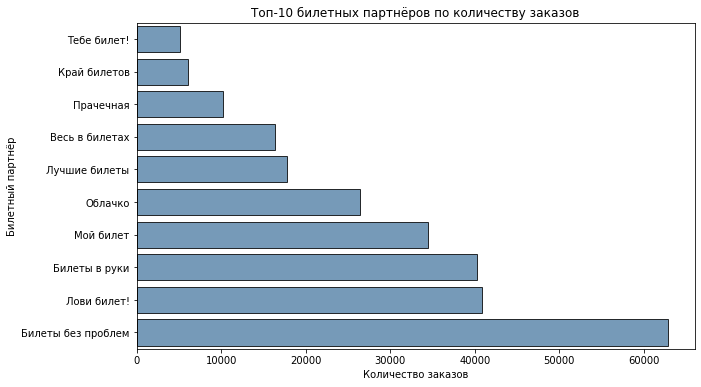

In [89]:
# Сортируем данные
top_partners_orders_plot = (top_partners_orders.sort_values('orders_count'))

# Задаём размер графика и фигуру
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_partners_orders_plot,
    y='service_name',
    x='orders_count',
    color='steelblue',
    edgecolor='black',
    alpha=0.8)

# Добавляем заголовок и подписи
plt.title('Топ-10 билетных партнёров по количеству заказов')
plt.xlabel('Количество заказов')
plt.ylabel('Билетный партнёр')

# Выводим график
plt.show()

In [90]:
# Выводим топ-10 партнёров по суммарной выручке
top_partners_revenue = (partner_stats.sort_values('revenue_rub', ascending=False).head(10))

# Выводим результат
top_partners_revenue

,service_name,events_count,orders_count,revenue_rub,orders_share_pct,revenue_share_pct
3,Билеты без проблем,4247,62858,24322192.40,21.84,16.30
24,Мой билет,1300,34440,22042364.72,11.97,14.77
25,Облачко,2335,26402,18588613.86,9.18,12.45
21,Лови билет!,4867,40802,16675475.08,14.18,11.17
8,Весь в билетах,855,16425,16533231.19,5.71,11.08
5,Билеты в руки,3530,40281,13194329.82,14.00,8.84
19,Край билетов,252,6109,6405689.22,2.12,4.29
26,Прачечная,1026,10222,4746810.52,3.55,3.18
13,Дом культуры,272,4412,4358655.99,1.53,2.92
35,Яблоко,714,5004,3868336.88,1.74,2.59


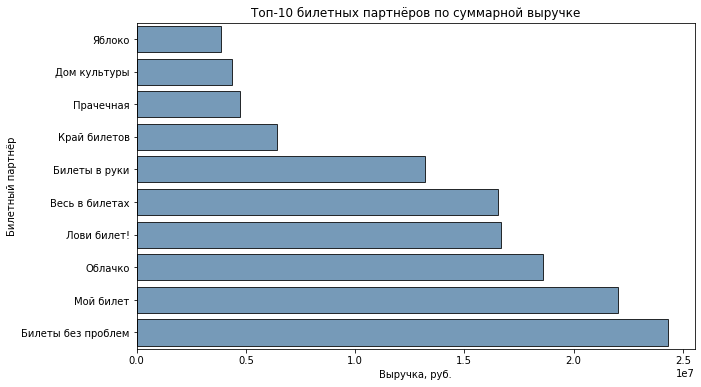

In [91]:
# Сортируем данные 
top_partners_revenue_plot = (top_partners_revenue.sort_values('revenue_rub'))

# Задаём размер графика и фигуру
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_partners_revenue_plot,
    y='service_name',
    x='revenue_rub',
    color='steelblue',
    edgecolor='black',
    alpha=0.8)

# Добавляем заголовок и подписи
plt.title('Топ-10 билетных партнёров по суммарной выручке')
plt.xlabel('Выручка, руб.')
plt.ylabel('Билетный партнёр')

# Выводим график
plt.show()

In [92]:
# Выводим топ-10 партнёров по количеству уникальных мероприятий
top_partners_events = (partner_stats.sort_values('events_count', ascending=False).head(10))

# Выводим результат
top_partners_events

,service_name,events_count,orders_count,revenue_rub,orders_share_pct,revenue_share_pct
21,Лови билет!,4867,40802,16675475.08,14.18,11.17
3,Билеты без проблем,4247,62858,24322192.40,21.84,16.30
5,Билеты в руки,3530,40281,13194329.82,14.00,8.84
25,Облачко,2335,26402,18588613.86,9.18,12.45
22,Лучшие билеты,1762,17741,2724060.58,6.17,1.83
24,Мой билет,1300,34440,22042364.72,11.97,14.77
30,Тебе билет!,1062,5190,2962303.12,1.80,1.98
26,Прачечная,1026,10222,4746810.52,3.55,3.18
8,Весь в билетах,855,16425,16533231.19,5.71,11.08
35,Яблоко,714,5004,3868336.88,1.74,2.59


In [93]:
# Рассчитываем долю заказов и выручки топ-10 партнёров
top10_partner_orders_share = (top_partners_orders['orders_count'].sum()/ total_orders * 100)
top10_partner_revenue_share = (top_partners_revenue['revenue_rub'].sum()/ total_revenue * 100)

print('Доля заказов топ-10 партнёров:',round(top10_partner_orders_share, 2),'%')
print('Доля выручки топ-10 партнёров:',round(top10_partner_revenue_share, 2),'%')

Доля заказов топ-10 партнёров: 90.52 %
Доля выручки топ-10 партнёров: 87.59 %


**Промежуточный вывод:**

- Распределение мероприятий и заказов по регионам неравномерно. Лидером является Каменевский регион: на него приходится 26,5% уникальных мероприятий и 31,2% заказов. В целом топ-10 регионов концентрируют 69,7% мероприятий и 71,7% заказов. При этом высокая доля заказов не всегда объясняется разнообразием предложения: например, Медовская область формирует 4,8% заказов при доле мероприятий 2,3%, а Озернинский край — 3,6% заказов при 1,6% мероприятий.
- Среди билетных партнёров распределение ещё более концентрировано: топ-10 партнёров обеспечивают 90,5% заказов и 87,6% выручки. При этом крупнейший партнёр "Билеты без проблем" формирует 21,8% заказов и 16,3% выручки. Таким образом, единственного доминирующего монополиста нет, однако значительная часть рынка сосредоточена у нескольких крупных игроков. По структуре такое распределение можно охарактеризовать как олигополистическое.
- Партнёры различаются не только масштабом, но и характером работы. "Лови билет!" предлагает наиболее широкий ассортимент — 4867 уникальных мероприятий, но его доля выручки относительно доли заказов ниже, что может указывать на более низкую среднюю стоимость заказов. Напротив, "Весь в билетах" обеспечивает только 5,7% заказов, но 11,1% выручки, что может говорить о специализации на более дорогих заказах или мероприятиях.
- Таким образом, среди партнёров можно выделить разные модели: одни работают с широким ассортиментом мероприятий и большим количеством заказов, другие имеют более узкое предложение, но получают относительно высокую выручку. Это позволяет оценивать партнёров не только по числу заказов, но и по ассортименту мероприятий и эффективности монетизации.

##  Статистический анализ данных

В рамках статистического анализа проверим две гипотезы о различиях в пользовательской активности между пользователями мобильных и стационарных устройств. Для анализа используем только данные осеннего периода — сентября и октября 2024 года

###  Подготовка выборок для статистического анализа

Перед проверкой гипотез сформируем независимые группы пользователей mobile и desktop. Часть пользователей могла оформлять заказы с обоих типов устройств, поэтому сначала проверим пересечение групп.

In [94]:
# Отбираем данные только за осенний период
autumn_test_df = df[df['month'].isin([9, 10])].copy()

# Выводим результат
print('Период:',autumn_test_df['created_dt_msk'].min(),'-',autumn_test_df['created_dt_msk'].max())
print('Количество строк:', len(autumn_test_df))

Период: 2024-09-01 00:00:00 - 2024-10-31 00:00:00
Количество строк: 168631


In [95]:
# Выделяем пользователей mobile
mobile_users = set(autumn_test_df.loc[
        autumn_test_df['device_type_canonical'] == 'mobile','user_id'])

# Выделяем пользователей desktop
desktop_users = set(autumn_test_df.loc[
        autumn_test_df['device_type_canonical'] == 'desktop','user_id'])

# Находим пользователей, которые использовали оба типа устройств
common_users = mobile_users & desktop_users

# Считаем общее количество уникальных пользователей
all_users = autumn_test_df['user_id'].nunique()

# Выводим результат
print('Уникальных пользователей mobile:', len(mobile_users))
print('Уникальных пользователей desktop:', len(desktop_users))
print('Пользователей в обеих группах:', len(common_users))
print('Доля пользователей в обеих группах:',round(len(common_users) / all_users * 100, 2),'%')

Уникальных пользователей mobile: 14192
Уникальных пользователей desktop: 4868
Пользователей в обеих группах: 3249
Доля пользователей в обеих группах: 20.55 %


In [96]:
# Исключаем пользователей, которые встречаются в обеих группах
autumn_independent = autumn_test_df[~autumn_test_df['user_id'].isin(common_users)].copy()

# Проверяем количество пользователей после исключения пересечений
print('Уникальных пользователей mobile:',
    autumn_independent.loc[autumn_independent['device_type_canonical'] == 'mobile','user_id'].nunique())
print('Уникальных пользователей desktop:',
    autumn_independent.loc[autumn_independent['device_type_canonical'] == 'desktop','user_id'].nunique())

Уникальных пользователей mobile: 10943
Уникальных пользователей desktop: 1619


###  Проверка гипотезы о среднем количестве заказов на пользователя

Проверим, действительно ли пользователи mobile в среднем оформляют больше заказов, чем пользователи desktop. В качестве единицы наблюдения используем пользователя и рассчитаем для каждого пользователя количество уникальных заказов за осенний период.

In [97]:
# Рассчитываем количество заказов для каждого пользователя
orders_user_test = (autumn_independent.groupby(['device_type_canonical', 'user_id'])['order_id']
    .nunique().reset_index(name='orders_count'))

# Выводим первые 5 строк
orders_user_test.head()

,device_type_canonical,user_id,orders_count
0,desktop,0040e12d70fae81,1
1,desktop,006d1660d830822,7
2,desktop,00bdfa36a6e542b,1
3,desktop,00cb8c1ef996876,2
4,desktop,00e62ce48c12cb4,2


In [98]:
# Рассчитываем основные показатели по группам
orders_user_stats = (orders_user_test.groupby('device_type_canonical')['orders_count']
    .agg(
        users_count='count',
        mean='mean',
        median='median',
        std='std').round(2))

# Выводим результат
orders_user_stats

,users_count,mean,median,std
device_type_canonical,,,,
desktop,1619,1.97,1,3.06
mobile,10943,2.86,2,4.10


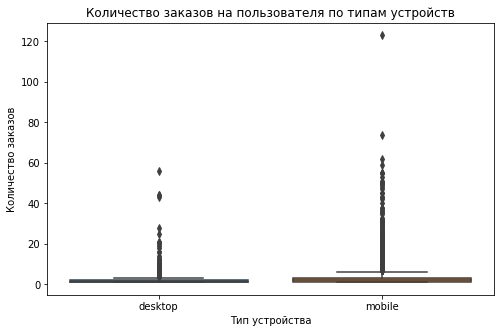

In [99]:
# Задаём размер графика и фигуру
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=orders_user_test,
    x='device_type_canonical',
    y='orders_count')

# Добавляем заголовок и подписи
plt.title('Количество заказов на пользователя по типам устройств')
plt.xlabel('Тип устройства')
plt.ylabel('Количество заказов')

# Выводим график
plt.show()

**Нулевая гипотеза H₀:** среднее количество заказов на пользователя mobile не выше среднего количества заказов на пользователя desktop:

μmobile ≤ μdesktop.

**Альтернативная гипотеза H₁:** среднее количество заказов на пользователя mobile выше среднего количества заказов на пользователя desktop:

μmobile > μdesktop.

Уровень статистической значимости: α = 0,05.

Для проверки гипотезы используем односторонний t-тест Уэлча для независимых выборок. Сравнивается среднее значение количественного показателя, а после исключения пользователей, использовавших оба типа устройств, выборки являются независимыми. Размеры выборок и их стандартные отклонения различаются, поэтому используем вариант t-теста, не предполагающий равенства дисперсий. Несмотря на асимметрию распределения, обе выборки имеют достаточно большой объём.

In [100]:
# Формируем выборку пользователей mobile
metric_mobile = orders_user_test.loc[
    orders_user_test['device_type_canonical'] == 'mobile','orders_count']

# Формируем выборку пользователей desktop
metric_desktop = orders_user_test.loc[
    orders_user_test['device_type_canonical'] == 'desktop','orders_count']

# Задаём уровень статистической значимости
alpha = 0.05

# Проводим односторонний t-тест Уэлча
statistic, p_value = stats.ttest_ind(
    metric_mobile,
    metric_desktop,
    equal_var=False,
    alternative='greater')

# Выводим результат
print(f't-статистика = {statistic:.4f}')
print(f'p-value = {p_value:.6f}')

if p_value < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не удалось отвергнуть нулевую гипотезу')

t-статистика = 10.3811
p-value = 0.000000
Отвергаем нулевую гипотезу


**Вывод:** p-value оказался меньше уровня статистической значимости α = 0,05, поэтому нулевая гипотеза отвергается. Получены статистически значимые основания утверждать, что пользователи mobile в среднем оформляют больше заказов, чем пользователи desktop. В исследуемых данных среднее количество заказов составляет 2,86 для пользователей mobile и 1,97 для пользователей desktop.

###  Проверка гипотезы о среднем времени между заказами

Проверим, выше ли среднее время между заказами у пользователей mobile по сравнению с пользователями desktop.

Для соблюдения условия задания интервалы будем рассчитывать непосредственно между последовательными заказами, совершёнными в сентябре и октябре 2024 года. Таким образом, в расчёт не попадут интервалы между осенним заказом и предыдущим заказом, сделанным летом.

In [101]:
# Сортируем осенние заказы пользователей по времени оформления
autumn_orders_sorted = (autumn_independent
    .sort_values(['device_type_canonical','user_id','created_ts_msk']).copy())

# Рассчитываем время между последовательными заказами одного пользователя
autumn_orders_sorted['days_between_orders'] = (
    autumn_orders_sorted.groupby(['device_type_canonical', 'user_id'])['created_ts_msk'].diff()
    .dt.total_seconds() / (24 * 60 * 60))

# Выводим первые строки 
autumn_orders_sorted[['device_type_canonical','user_id','created_ts_msk','days_between_orders']].head(10)

,device_type_canonical,user_id,created_ts_msk,days_between_orders
88,desktop,0040e12d70fae81,2024-09-02 19:49:14,NaN
122,desktop,006d1660d830822,2024-09-01 16:43:50,NaN
123,desktop,006d1660d830822,2024-09-25 13:18:41,23.857535
124,desktop,006d1660d830822,2024-09-29 17:02:46,4.155613
125,desktop,006d1660d830822,2024-10-03 15:04:48,3.918079
126,desktop,006d1660d830822,2024-10-15 17:24:55,12.097303
127,desktop,006d1660d830822,2024-10-15 17:25:32,0.000428
128,desktop,006d1660d830822,2024-10-18 14:13:17,2.866493
214,desktop,00bdfa36a6e542b,2024-10-17 09:42:12,NaN
222,desktop,00cb8c1ef996876,2024-10-21 22:44:05,NaN


In [102]:
# Рассчитываем среднее время между осенними заказами для каждого пользователя
days_between_orders = (autumn_orders_sorted.dropna(subset=['days_between_orders'])
    .groupby(['device_type_canonical', 'user_id'])['days_between_orders']
    .mean().reset_index(name='mean_days_between_orders'))

# Выводим первые строки
days_between_orders.head()

,device_type_canonical,user_id,mean_days_between_orders
0,desktop,006d1660d830822,7.815909
1,desktop,00cb8c1ef996876,0.452188
2,desktop,00e62ce48c12cb4,0.035185
3,desktop,00f5131ed2d9533,0.005437
4,desktop,010eb7e9b243cbc,0.002263


In [103]:
# Рассчитываем основные показатели по группам
days_stats = (days_between_orders.groupby('device_type_canonical')['mean_days_between_orders']
    .agg(
        users_count='count',
        mean='mean',
        median='median',
        std='std').round(2))

# Выводим результат
days_stats

,users_count,mean,median,std
device_type_canonical,,,,
desktop,579,3.96,0.01,8.94
mobile,5569,6.68,3.09,9.37


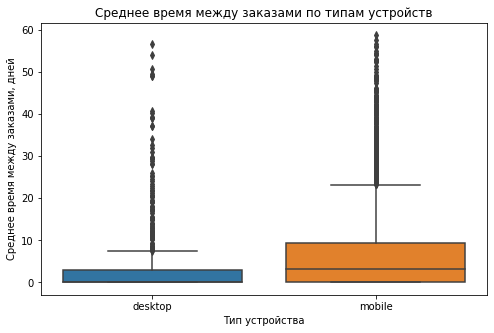

In [104]:
# Задаём размер графика
plt.figure(figsize=(8, 5))

# Строим диаграмму размаха
sns.boxplot(
    data=days_between_orders,
    x='device_type_canonical',
    y='mean_days_between_orders'
)

# Добавляем заголовок и подписи
plt.title('Среднее время между заказами по типам устройств')
plt.xlabel('Тип устройства')
plt.ylabel('Среднее время между заказами, дней')

plt.show()

**Нулевая гипотеза H₀:** среднее время между заказами пользователей mobile не выше среднего времени между заказами пользователей desktop:

μmobile ≤ μdesktop.

**Альтернативная гипотеза H₁:** среднее время между заказами пользователей mobile выше среднего времени между заказами пользователей desktop:

μmobile > μdesktop.

Уровень статистической значимости: α = 0,05.

Для проверки гипотезы также используем односторонний t-тест Уэлча для независимых выборок. В качестве наблюдения используется среднее время между заказами отдельного пользователя. Выборки пользователей mobile и desktop независимы, а использование теста Уэлча позволяет не предполагать равенство дисперсий в группах. Несмотря на асимметрию распределений, объёмы выборок достаточно велики — 5569 пользователей mobile и 579 пользователей desktop, поэтому t-тест Уэлча применим для сравнения средних.

In [105]:
# Формируем выборку пользователей mobile
metric_mobile = days_between_orders.loc[
    days_between_orders['device_type_canonical'] == 'mobile','mean_days_between_orders']

# Формируем выборку пользователей desktop
metric_desktop = days_between_orders.loc[
    days_between_orders['device_type_canonical'] == 'desktop','mean_days_between_orders']

# Задаём уровень статистической значимости
alpha = 0.05

# Проводим односторонний t-тест Уэлча
statistic, p_value = stats.ttest_ind(
    metric_mobile,
    metric_desktop,
    equal_var=False,
    alternative='greater')

# Выводим результат
print(f'Среднее mobile: {metric_mobile.mean():.2f} дня')
print(f'Среднее desktop: {metric_desktop.mean():.2f} дня')
print(f't-статистика = {statistic:.4f}')
print(f'p-value = {p_value:.6f}')

if p_value < alpha:
    print('Отвергаем нулевую гипотезу')
    print('Среднее время между заказами пользователей mobile '
          'статистически значимо выше, чем у пользователей desktop.')
else:
    print('Не удалось отвергнуть нулевую гипотезу')
    print('Недостаточно статистических оснований утверждать, '
          'что среднее время между заказами пользователей mobile '
          'выше, чем у пользователей desktop.')

Среднее mobile: 6.68 дня
Среднее desktop: 3.96 дня
t-статистика = 6.9432
p-value = 0.000000
Отвергаем нулевую гипотезу
Среднее время между заказами пользователей mobile статистически значимо выше, чем у пользователей desktop.


**Вывод:** p-value оказался значительно меньше уровня статистической значимости α = 0,05, поэтому нулевая гипотеза отвергается.

Получены статистически значимые основания утверждать, что среднее время между заказами пользователей mobile выше, чем у пользователей desktop. В исследуемых данных среднее время между заказами составляет 6,68 дня для пользователей mobile и 3,96 дня для пользователей desktop.

**Промежуточный вывод:**

- Первая гипотеза получила статистическое подтверждение. Пользователи mobile осенью оформляли в среднем 2,86 заказа на пользователя против 1,97 заказа у пользователей desktop. p-value < 0,000001, поэтому нулевая гипотеза отвергнута.
- Вторая гипотеза также получила статистическое подтверждение. Среднее время между осенними заказами пользователей mobile составило 6,68 дня против 3,96 дня у пользователей desktop. p-value < 0,000001, поэтому нулевая гипотеза также отвергнута.
- Таким образом, пользователи mobile в среднем оформляют больше заказов, а средний интервал между их последовательными заказами также выше, чем у пользователей desktop. Обнаруженные различия статистически значимы.

##  Общий вывод и рекомендации

###  Общий вывод:

В рамках проекта были проанализированы данные сервиса продажи билетов за период с июня по октябрь 2024 года. Исходные данные включали информацию о 290 849 заказах, 22 427 мероприятиях и курсах тенге. После объединения, обработки выбросов и дубликатов в итоговом датафрейме осталось 287 752 записи.

- Количество заказов росло на протяжении всего рассматриваемого периода: с 34 164 в июне до 99 279 в октябре, то есть примерно в 2,9 раза. Особенно заметно рост ускорился осенью.
- Концерты остались самой востребованной категорией, хотя их доля снизилась с 42,6% летом до 37,2% осенью. Одновременно выросла доля театральных мероприятий с 20,1% до 25,3%, а спорта — с 2,5% до 11,2%.
- Средняя выручка с одного билета осенью снизилась для большинства типов мероприятий. Наиболее заметное снижение наблюдалось в театре (-17,8%), категории «ёлки» (-15,4%) и концертах (-12,0%). Рост наблюдался только у стендапа и выставок.
- Осенью пользовательская активность в целом увеличивалась от сентября к октябрю. В среднем за день оформлялось около 2 764 заказов при DAU около 924 пользователей. В будни активность была выше, чем в выходные, однако средняя стоимость одного билета в выходные была выше.
- Распределение заказов по регионам достаточно концентрированное. Каменевский регион является лидером: на него приходится 26,5% уникальных мероприятий и 31,2% заказов. Топ-10 регионов обеспечивают около 71,7% всех заказов.
- Среди билетных партнёров лидирует «Билеты без проблем» по количеству заказов и суммарной выручке, а «Лови билет!» — по количеству уникальных мероприятий. Топ-10 партнёров обеспечивают 90,5% заказов и 87,6% выручки, что говорит о высокой концентрации заказов у крупнейших партнёров.
- Статистический анализ подтвердил обе проверяемые гипотезы. Пользователи mobile совершают в среднем больше заказов, чем пользователи desktop: 2,86 против 1,97. Среднее время между осенними заказами у пользователей mobile также статистически значимо выше — 6,68 дня против 3,96 дня у desktop.

###  Рекомендации:

- Учитывать выраженный рост спроса осенью при планировании ассортимента мероприятий и нагрузки на сервис, особенно в быстрорастущих категориях спорта и театра.
- Дополнительно исследовать причины снижения средней выручки с одного билета в крупных категориях, прежде всего в театре и концертах: изменение цен, структуры мероприятий, скидок или пользовательского спроса.
- Сохранять фокус на крупнейших регионах, одновременно изучая регионы, где доля заказов заметно превышает долю мероприятий: это может указывать на потенциал для расширения предложения.
- Контролировать высокую зависимость от крупнейших билетных партнёров и дополнительно анализировать эффективность партнёров не только по количеству заказов, но и по выручке.
- Учитывать различия между mobile и desktop при развитии продукта. Mobile обеспечивает больше заказов на пользователя, однако более высокий интервал между заказами требует дополнительного изучения поведения пользователей и причин таких различий.